### Package Installation and loading

**Note**: Please upload the 'merged_data_with_RER.csv' file attached in the /content folder on drive.

In [ ]:
install.packages(c("tidyverse", "skimr", "janitor", "corrplot","googledrive", "patchwork", "scales", "reshape2", "tseries"))

library(tidyverse)   # Collection for data manipulation and visualization (dplyr, ggplot2, tidyr, readr etc.)
library(skimr)       # Quick summary statistics with skim()
library(janitor)     # Cleans messy column names using clean_names() for consistent formatting
library(corrplot)    # Visualizes heatmaps to explore relationships between log variables
library(googledrive) # Authenticates and accesses Google Drive to load/save dataset files from cloud storage
library(scales)      # Formats axis labels and values in ggplot2 plots
library(reshape2)    # Reshapes data between wide and long format using melt() for multi-variable ggplot2 charts
library(tseries)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘snakecase’, ‘plyr’, ‘quadprog’, ‘zoo’, ‘quantmod’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


corrplot 0.95 loaded


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:


In [ ]:
in_colab <- Sys.getenv("COLAB_RELEASE_TAG") != "" ||
  file.exists("/content")

if (in_colab)
{ # ---- Colab: Trigger file upload from your computer ---- # This uses the built-in Colab R file upload mechanism. # When this runs, a file picker dialog will appear in your browser. cat("=== COLAB DETECTED ===\n")
cat("Please upload 'merged_data_with_RER.csv' using the file\n")
cat("browser on the LEFT panel in Colab (folder icon), then\n")
cat("the script will read it from /content/ automatically.\n\n")

# Wait for user to upload — file will land in /content/
data_path <- "/content/merged_data_with_RER.csv"

# If the file is not there yet, pause and tell the user
if (!file.exists(data_path)) {
  stop(paste(
    "File not found at",
  data_path, "\nPlease upload 'merged_data_with_RER.csv' via the Colab",
             "file browser (left panel > upload icon) and re-run this cell." ))
             }
  } else { # ---- Local RStudio: set path to wherever your file is ----
             # Change this path to match your local machine if needed.
             data_path <- "/merged_data_with_RER.csv" # If not in working directory, use file.choose() for a GUI file picker: #
             data_path <- file.choose()
          }

cat("Reading data from:", data_path, "\n")

Please upload 'merged_data_with_RER.csv' using the file
browser on the LEFT panel in Colab (folder icon), then
the script will read it from /content/ automatically.

Reading data from: /content/merged_data_with_RER.csv 


# Dataset loaded

In [ ]:
df <- read.csv(data_path) #Load the file

# Previewing the dataset

In [ ]:
head(df)
summary(df)
skim(df)
sum(is.na(df))

,date,CPI_Ireland,CPI_USA,NER,RER
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,2015-01,98.7,99.05,1.1291,1.1331
2,2015-02,99.3,99.30,1.1340,1.1340
3,2015-03,100.0,99.57,1.0822,1.0775
4,2015-04,99.9,99.67,1.0742,1.0717
5,2015-05,100.4,100.00,1.1145,1.1101
6,2015-06,100.8,100.28,1.1203,1.1145


     date            CPI_Ireland       CPI_USA            NER        
 Length:132         Min.   : 98.7   Min.   : 99.05   Min.   :0.9904  
 Class :character   1st Qu.:100.4   1st Qu.:104.04   1st Qu.:1.0861  
 Mode  :character   Median :101.8   Median :109.36   Median :1.1163  
                    Mean   :107.1   Mean   :114.76   Mean   :1.1197  
                    3rd Qu.:117.0   3rd Qu.:127.46   3rd Qu.:1.1577  
                    Max.   :123.4   Max.   :137.56   Max.   :1.2316  
      RER       
 Min.   :1.072  
 1st Qu.:1.146  
 Median :1.190  
 Mean   :1.197  
 3rd Qu.:1.241  
 Max.   :1.341  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,date,0,1,7,7,0,132,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,CPI_Ireland,0,1,NA,NA,NA,NA,NA,107.101515,8.54033077,98.7000,100.400000,101.8000,116.9750,123.4000,▇▁▁▁▃
3,numeric,CPI_USA,0,1,NA,NA,NA,NA,NA,114.764621,12.57320138,99.0500,104.040000,109.3650,127.4575,137.5600,▇▅▂▃▅
4,numeric,NER,0,1,NA,NA,NA,NA,NA,1.119733,0.05102585,0.9904,1.086075,1.1163,1.1577,1.2316,▁▅▇▅▂
5,numeric,RER,0,1,NA,NA,NA,NA,NA,1.197278,0.06896885,1.0717,1.145675,1.1902,1.2411,1.3406,▅▅▇▃▃


[1] 0

# Checking the missing value for each column

In [ ]:
sapply(df, function(x) sum(is.na(x)) / length(x) * 100)

date CPI_Ireland     CPI_USA         NER         RER 
          0           0           0           0           0

In [ ]:
df <- df %>% distinct()

# Standardizing the column name

In [ ]:
df <- df %>% clean_names()
colnames(df)

[1] "date"        "cpi_ireland" "cpi_usa"     "ner"         "rer"

# PART C : DATA TRANSFORMATION  by converting raw economic variables  into natural logarithms variables

In [ ]:
df <- df %>%
  mutate(
    log_ner = log(ner),
    log_rer = log(rer),
    log_cpi_ireland = log(cpi_ireland),
    log_cpi_usa = log(cpi_usa)
  )

In [ ]:
skim(df)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,date,0,1,7,7,0,132,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,cpi_ireland,0,1,NA,NA,NA,NA,NA,107.1015152,8.54033077,98.700000000,100.40000000,101.8000000,116.9750000,123.4000000,▇▁▁▁▃
3,numeric,cpi_usa,0,1,NA,NA,NA,NA,NA,114.7646212,12.57320138,99.050000000,104.04000000,109.3650000,127.4575000,137.5600000,▇▅▂▃▅
4,numeric,ner,0,1,NA,NA,NA,NA,NA,1.1197333,0.05102585,0.990400000,1.08607500,1.1163000,1.1577000,1.2316000,▁▅▇▅▂
5,numeric,rer,0,1,NA,NA,NA,NA,NA,1.1972780,0.06896885,1.071700000,1.14567500,1.1902000,1.2411000,1.3406000,▅▅▇▃▃
6,numeric,log_ner,0,1,NA,NA,NA,NA,NA,0.1120600,0.04558384,-0.009646377,0.08257028,0.1100183,0.1464349,0.2083141,▁▃▇▅▃
7,numeric,log_rer,0,1,NA,NA,NA,NA,NA,0.1784132,0.05737661,0.069246173,0.13599338,0.1741214,0.2159976,0.2931173,▃▅▇▂▅
8,numeric,log_cpi_ireland,0,1,NA,NA,NA,NA,NA,4.6707254,0.07775987,4.592084946,4.60916221,4.6230101,4.7619596,4.8154311,▇▁▁▁▃
9,numeric,log_cpi_usa,0,1,NA,NA,NA,NA,NA,4.7370748,0.10751240,4.595624773,4.64477539,4.6946909,4.8477819,4.9240602,▇▇▂▃▆


Preparing data for visualization
# Converting the date column to a proper Date object for plotting
# Assuming format is 'YYYY-MM'

In [ ]:
df$date_obj <- ym(df$date)

# Saving the processed data

In [ ]:
# Create folder if not exists
dir.create("/content/drive/MyDrive/EC6011", recursive = TRUE)

# Save file
file_path <- "/content/drive/MyDrive/EC6011/merged_data_with_logs_R.csv"

write.csv(df, file_path, row.names = FALSE)

print("File saved successfully")

[1] "File saved successfully"


# PART D :

Log Transformations and Visualizations
First-Differenced ADF, PP & KPSS Tests
In this section we are running ADF, PP and KPSS tests on the H0 level & the first differences for all log variables to confirm they
are integrated of order one, I(1).

# Time series plots for the variables

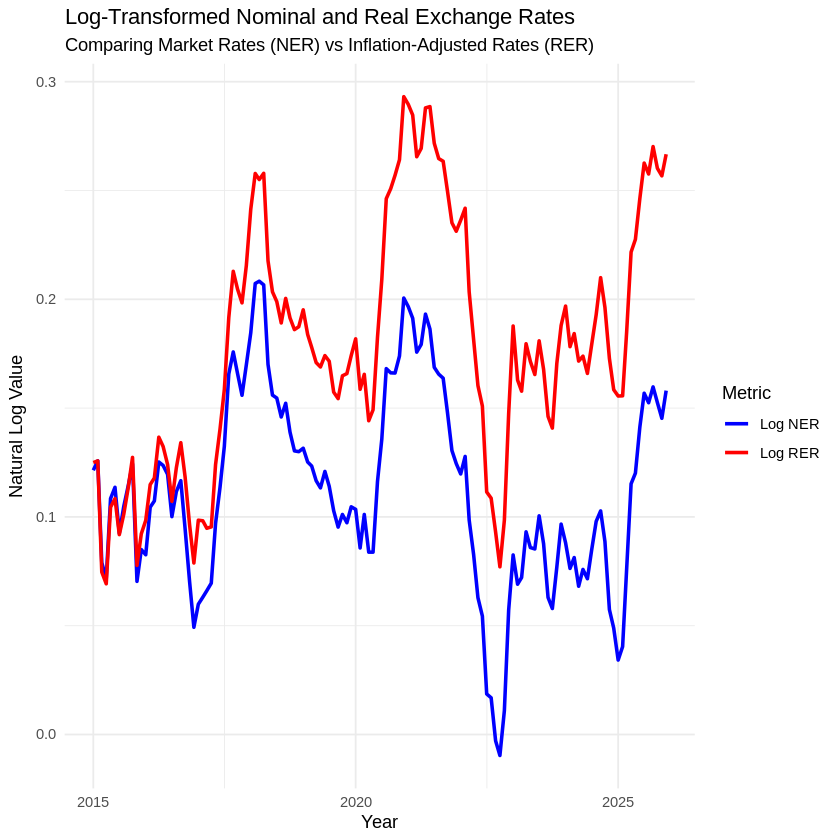

In [ ]:

df_exch_long <- df %>%
  select(date_obj, log_ner, log_rer) %>%
  pivot_longer(cols = -date_obj, names_to = "Variable", values_to = "Log_Value")
plot_exch <- ggplot(df_exch_long, aes(x = date_obj, y = Log_Value, color = Variable)) +
  geom_line(linewidth = 1) +
  labs(title = "Log-Transformed Nominal and Real Exchange Rates",
       subtitle = "Comparing Market Rates (NER) vs Inflation-Adjusted Rates (RER)",
       x = "Year", y = "Natural Log Value",
       color = "Metric") +
  theme_minimal() +
  scale_color_manual(values = c("blue", "red"),
                     labels = c("Log NER", "Log RER"))
print(plot_exch)



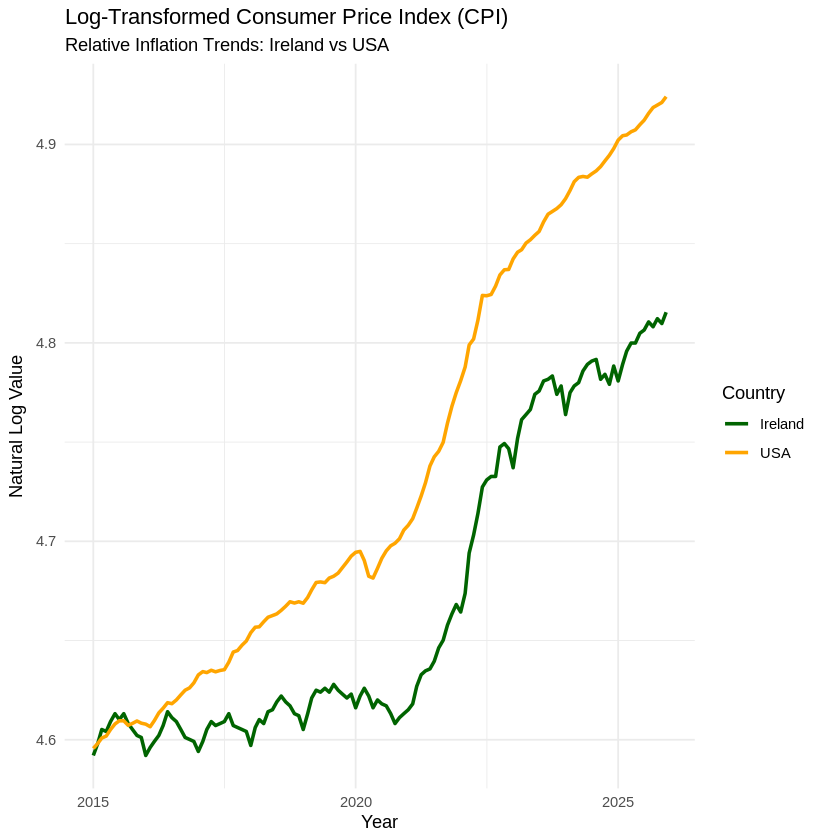

In [ ]:
df_cpi_long <- df %>%
  select(date_obj, log_cpi_ireland, log_cpi_usa) %>%
  pivot_longer(cols = -date_obj, names_to = "Variable", values_to = "Log_Value")

plot_cpi <- ggplot(df_cpi_long, aes(x = date_obj, y = Log_Value, color = Variable)) +
  geom_line(linewidth = 1) +
  labs(title = "Log-Transformed Consumer Price Index (CPI)",
       subtitle = "Relative Inflation Trends: Ireland vs USA",
       x = "Year", y = "Natural Log Value",
       color = "Country") +
  theme_minimal() +
  scale_color_manual(values = c("darkgreen", "orange"),
                     labels = c("Ireland", "USA"))

print(plot_cpi)

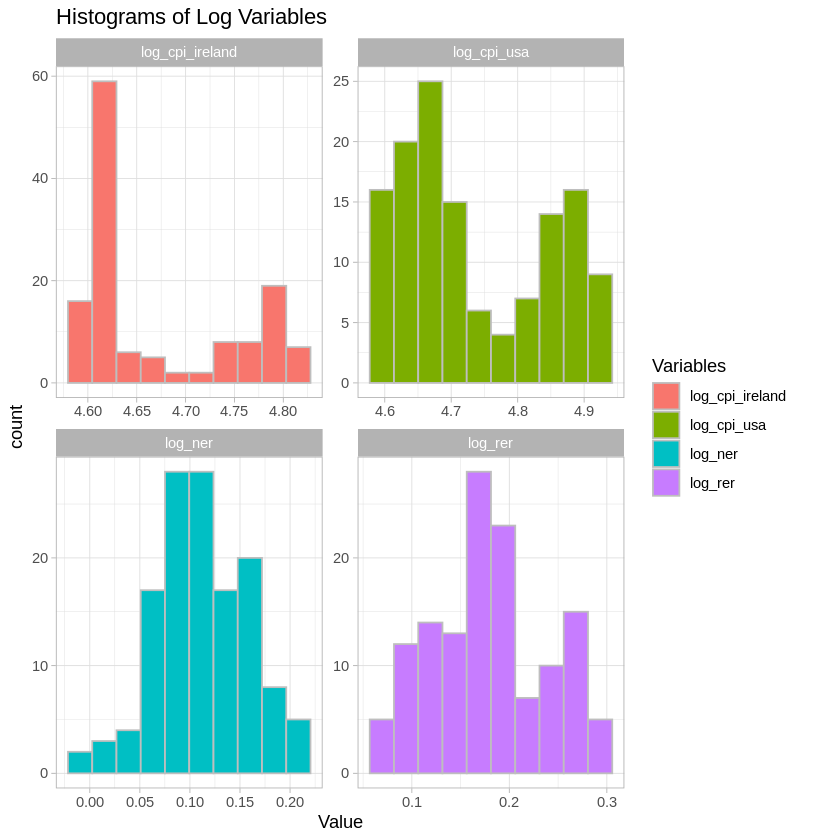

In [ ]:
# Prepare data (Long Format)
library(tidyr)
df_long <- df %>%
  select(log_ner, log_rer, log_cpi_ireland, log_cpi_usa) %>%
  pivot_longer(cols = everything(), names_to = "Variables", values_to = "Value")

# Plot Histogram
ggplot(df_long, aes(x = Value, fill = Variables)) +
  geom_histogram(bins = 10, color = "grey") +
  facet_wrap(~Variables, scales = "free") +
  theme_light() +
  labs(title = "Histograms of Log Variables")

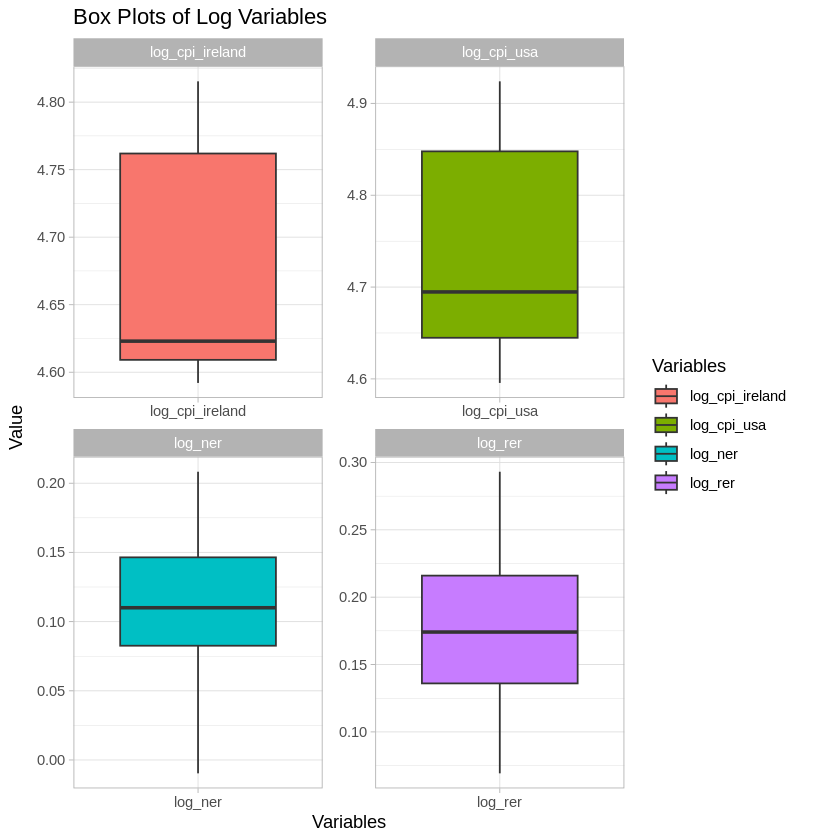

In [ ]:
# Plot Box Plot
ggplot(df_long, aes(x = Variables, y = Value, fill = Variables)) +
  geom_boxplot() +
  facet_wrap(~Variables, scales = "free") +
  theme_light() +
  labs(title = "Box Plots of Log Variables")

# ACF & PACF for the log variables and their First differences


=== ACF & PACF for Log CPI Ireland and its first difference ===



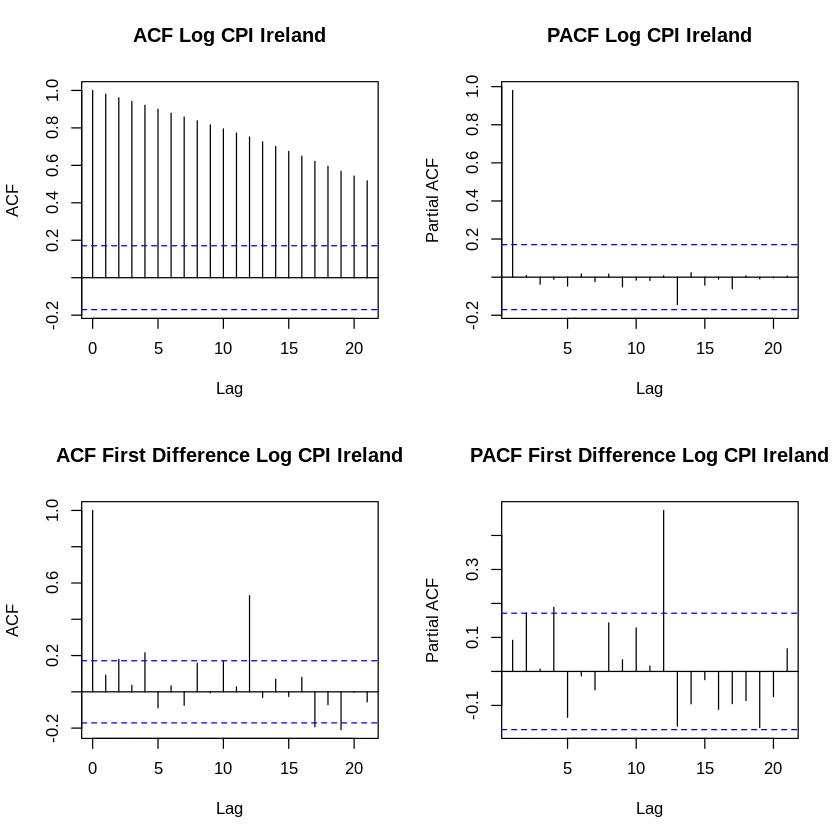

In [ ]:
cat("\n=== ACF & PACF for Log CPI Ireland and its first difference ===\n\n")

par(mfrow = c(2,2))
acf(df$log_cpi_ireland, main = "ACF Log CPI Ireland")
pacf(df$log_cpi_ireland, main = "PACF Log CPI Ireland")
acf(diff(df$log_cpi_ireland), main = "ACF First Difference Log CPI Ireland")
pacf(diff(df$log_cpi_ireland), main = "PACF First Difference Log CPI Ireland")


=== ACF & PACF for Log CPI USA and its first difference ===



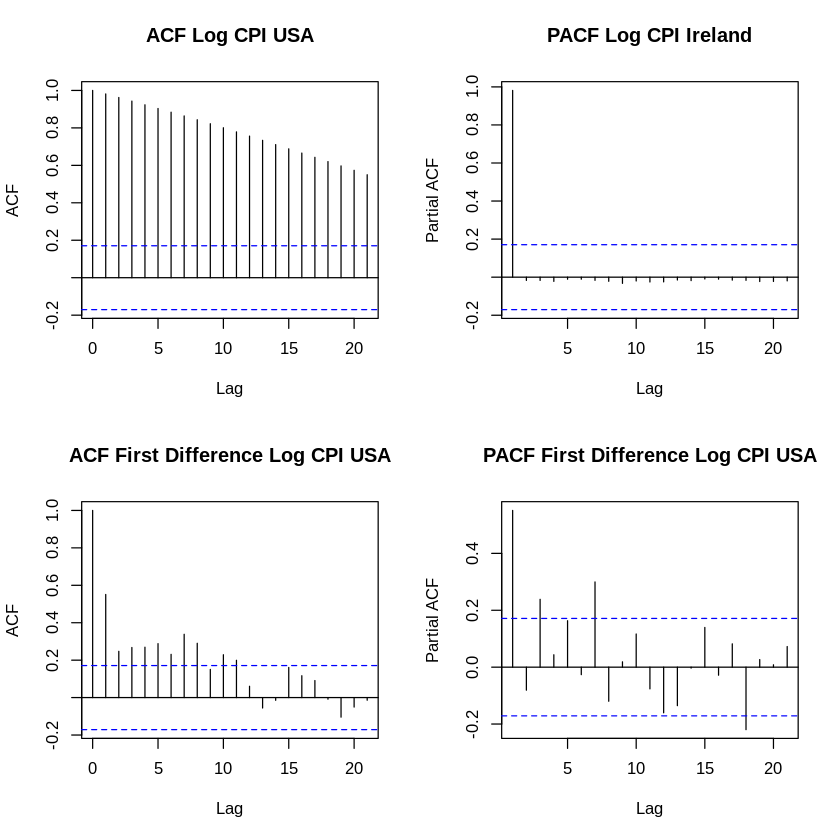

In [ ]:
cat("\n=== ACF & PACF for Log CPI USA and its first difference ===\n\n")

par(mfrow = c(2,2))
acf(df$log_cpi_usa, main = "ACF Log CPI USA")
pacf(df$log_cpi_usa, main = "PACF Log CPI Ireland")
acf(diff(df$log_cpi_usa), main = "ACF First Difference Log CPI USA")
pacf(diff(df$log_cpi_usa), main = "PACF First Difference Log CPI USA")


=== ACF & PACF for Log RER and its first difference ===



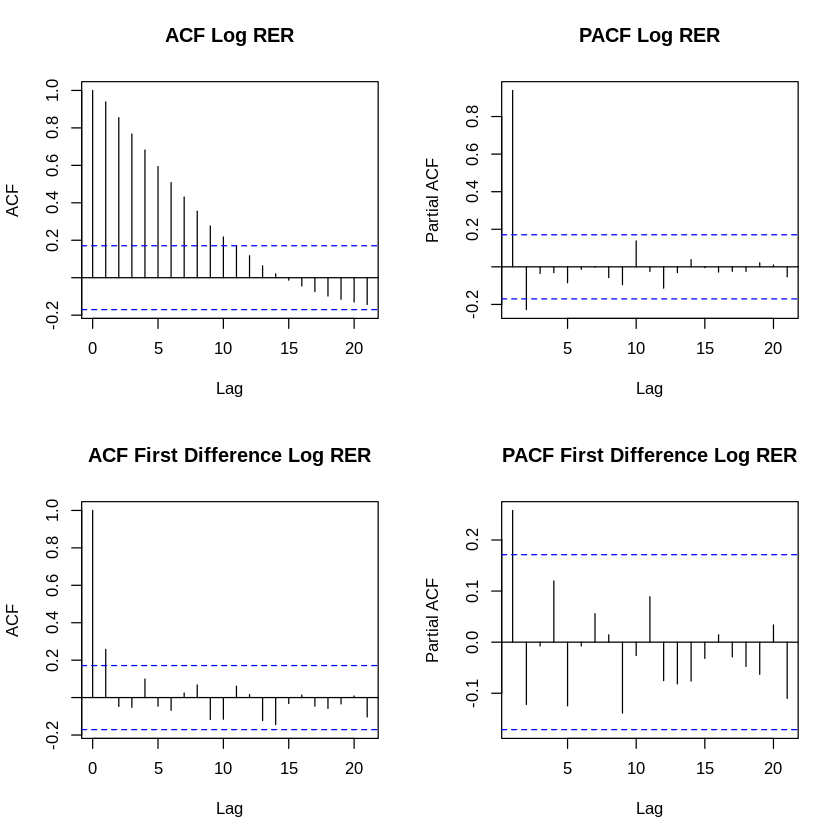

In [ ]:
cat("\n=== ACF & PACF for Log RER and its first difference ===\n\n")
par(mfrow = c(2,2))

acf(df$log_rer, main="ACF Log RER")
pacf(df$log_rer, main="PACF Log RER")
acf(diff(df$log_rer), main = "ACF First Difference Log RER")
pacf(diff(df$log_rer), main = "PACF First Difference Log RER")


=== ACF & PACF for Log NER and its first difference ===



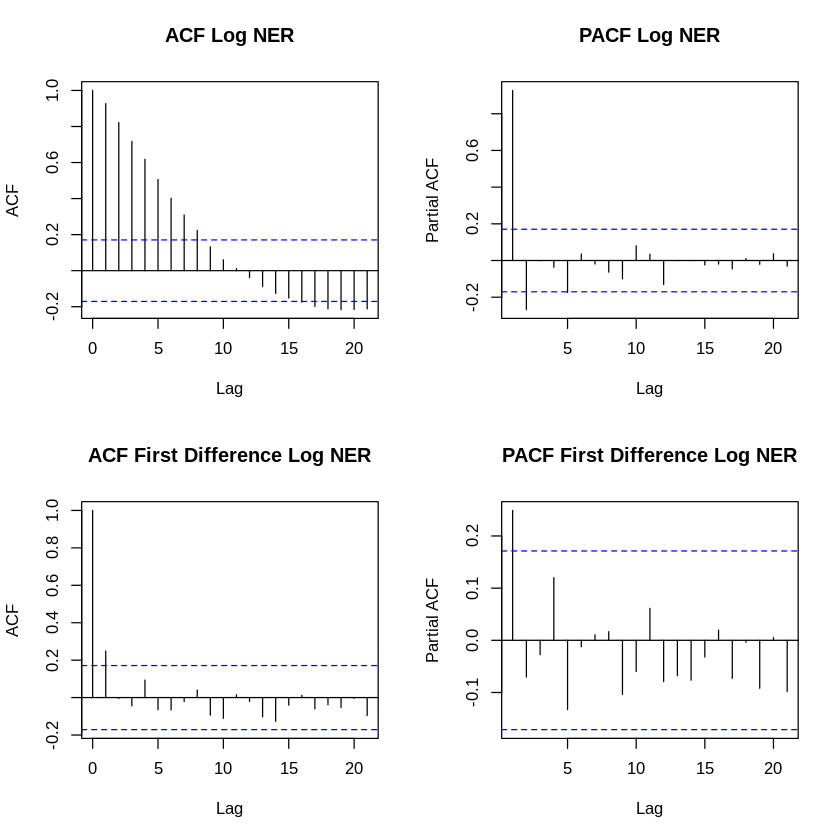

In [ ]:
cat("\n=== ACF & PACF for Log NER and its first difference ===\n\n")

par(mfrow = c(2,2))
acf(df$log_ner, main="ACF Log NER")
pacf(df$log_ner, main="PACF Log NER")
acf(diff(df$log_ner), main = "ACF First Difference Log NER")
pacf(diff(df$log_ner), main ="PACF First Difference Log NER")


# Storing as time series objects (monthly data starting Jan 2015)

In [ ]:
log_ner_ts <- ts(df$log_ner, start=c(2015,1), frequency=12)
log_rer_ts <- ts(df$log_rer, start=c(2015,1), frequency=12)
log_cpi_ire_ts <- ts(df$log_cpi_ireland, start=c(2015,1), frequency=12)
log_cpi_usa_ts <- ts(df$log_cpi_usa, start=c(2015,1), frequency=12)

In [ ]:
d_log_ner <- diff(log_ner_ts, differences=1)
d_log_rer <- diff(log_rer_ts, differences=1)
d_log_cpi_ire <- diff(log_cpi_ire_ts, differences=1)
d_log_cpi_usa <- diff(log_cpi_usa_ts, differences=1)

# ADF TEST FOR ALL LOG VARIABLES

In [ ]:
cat("=============================================================\n")
cat("         ADF TEST RESULTS - DETAILED OUTPUT                     \n")
cat("=============================================================\n\n")

adf_ner_level <- adf.test(log_ner_ts)
adf_rer_level <- adf.test(log_rer_ts)
adf_ire_level <- adf.test(log_cpi_ire_ts)
adf_usa_level <- adf.test(log_cpi_usa_ts)

adf_ner_diff <- adf.test(d_log_ner)
adf_rer_diff <- adf.test(d_log_rer)
adf_ire_diff <- adf.test(d_log_cpi_ire)
adf_usa_diff <- adf.test(d_log_cpi_usa)

# --- SUMMARY TABLE ---
cat("\n=============================================================\n")
cat("SUMMARY: ADF TEST RESULT\n")
cat("=============================================================\n")
cat(sprintf("%-25s %-12s %-10s %-12s %s\n", "Variable", "Statistic", "Lag", "p-value", "Decision"))
cat(strrep("-", 75), "\n")

adf_results <- list(
  list("log_ner (H0 level)",      adf_ner_level),
  list("log_rer (H0 level)",      adf_rer_level),
  list("log_cpi_ireland (H0 level)", adf_ire_level),
  list("log_cpi_usa (H0 level)",  adf_usa_level),
  list("d_log_ner",             adf_ner_diff),
  list("d_log_rer",             adf_rer_diff),
  list("d_log_cpi_ireland",     adf_ire_diff),
  list("d_log_cpi_usa",         adf_usa_diff)
)

for (r in adf_results) {
  label    <- r[[1]]
  test     <- r[[2]]
  stat     <- round(test$statistic, 4)
  lag      <- test$parameter
  pval     <- test$p.value
  pstr     <- ifelse(pval < 0.01, "< 0.01",
              ifelse(pval > 0.99, "> 0.99", round(pval, 4)))
  decision <- ifelse(pval < 0.05,
                     "Reject H0 (stationary)",
                     "Fail to reject H0 (unit root)")
  cat(sprintf("%-25s %-12s %-10s %-12s %s\n", label, stat, lag, pstr, decision))
}

cat(strrep("=", 75), "\n")
cat("Note: ADF null hypothesis = series contains a unit root.\n")
cat("      Rejecting H0 = evidence of stationarity.\n")
cat("      Lag order selected automatically by R (default method).\n")
cat(strrep("=", 75), "\n")


         ADF TEST RESULTS - DETAILED OUTPUT                     



Warning message in adf.test(d_log_ner):
“p-value smaller than printed p-value”
Warning message in adf.test(d_log_rer):
“p-value smaller than printed p-value”
Warning message in adf.test(d_log_cpi_ire):
“p-value smaller than printed p-value”



SUMMARY: ADF TEST RESULT
Variable                  Statistic    Lag        p-value      Decision
--------------------------------------------------------------------------- 
log_ner (H0 level)        -2.6481      5          0.307        Fail to reject H0 (unit root)
log_rer (H0 level)        -2.4983      5          0.3693       Fail to reject H0 (unit root)
log_cpi_ireland (H0 level) -1.8931      5          0.6209       Fail to reject H0 (unit root)
log_cpi_usa (H0 level)    -2.2591      5          0.4687       Fail to reject H0 (unit root)
d_log_ner                 -4.5971      5          0.01         Reject H0 (stationary)
d_log_rer                 -4.552       5          0.01         Reject H0 (stationary)
d_log_cpi_ireland         -4.3341      5          0.01         Reject H0 (stationary)
d_log_cpi_usa             -2.9986      5          0.1613       Fail to reject H0 (unit root)
Note: ADF null hypothesis = series contains a unit root.
      Rejecting H0 = evidence of stationarit

# PHILLIPS-PERRON TEST FOR ALL LOG VARIABLES




In [ ]:
cat("\n=============================================================\n")
cat("         PHILLIPS-PERRON TEST RESULTS - DETAILED OUTPUT         \n")
cat("=============================================================\n\n")

# --- LEVELS ---
cat("--- LEVELS (H0: Series contains a unit root) ---\n\n")

pp_ner_level <- pp.test(log_ner_ts)
pp_rer_level <- pp.test(log_rer_ts)
pp_ire_level <- pp.test(log_cpi_ire_ts)
pp_usa_level <- pp.test(log_cpi_usa_ts)


# --- FIRST DIFFERENCES ---
cat("\n--- FIRST DIFFERENCES (H0: Series contains a unit root) ---\n\n")

pp_ner_diff <- pp.test(d_log_ner)
pp_rer_diff <- pp.test(d_log_rer)
pp_ire_diff <- pp.test(d_log_cpi_ire)
pp_usa_diff <- pp.test(d_log_cpi_usa)



# --- SUMMARY TABLE ---
cat("\n=============================================================\n")
cat("SUMMARY: PHILLIPS-PERRON TEST RESULT\n")
cat("=============================================================\n")
cat(sprintf("%-25s %-12s %-10s %-12s %s\n", "Variable", "Statistic", "Lag", "p-value", "Decision"))
cat(strrep("-", 75), "\n")

pp_results <- list(
  list("log_ner (levels)",      pp_ner_level),
  list("log_rer (levels)",      pp_rer_level),
  list("log_cpi_ireland (lvl)", pp_ire_level),
  list("log_cpi_usa (levels)",  pp_usa_level),
  list("d_log_ner",             pp_ner_diff),
  list("d_log_rer",             pp_rer_diff),
  list("d_log_cpi_ireland",     pp_ire_diff),
  list("d_log_cpi_usa",         pp_usa_diff)
)

for (r in pp_results) {
  label    <- r[[1]]
  test     <- r[[2]]
  stat     <- round(test$statistic, 4)
  lag      <- test$parameter
  pval     <- test$p.value
  pstr     <- ifelse(pval < 0.01, "< 0.01",
              ifelse(pval > 0.99, "> 0.99", round(pval, 4)))
  decision <- ifelse(pval < 0.05,
                     "Reject H0 (stationary)",
                     "Fail to reject H0 (unit root)")
  cat(sprintf("%-25s %-12s %-10s %-12s %s\n", label, stat, lag, pstr, decision))
}

cat(strrep("=", 75), "\n")
cat("Note: PP null hypothesis = series contains a unit root.\n")
cat("      Rejecting H0 = evidence of stationarity.\n")
cat("      PP test uses Newey-West correction for serial correlation.\n")
cat("      Truncation lag selected automatically using R default.\n")
cat(strrep("=", 75), "\n")


         PHILLIPS-PERRON TEST RESULTS - DETAILED OUTPUT         

--- LEVELS (H0: Series contains a unit root) ---


--- FIRST DIFFERENCES (H0: Series contains a unit root) ---



Warning message in pp.test(d_log_ner):
“p-value smaller than printed p-value”
Warning message in pp.test(d_log_rer):
“p-value smaller than printed p-value”
Warning message in pp.test(d_log_cpi_ire):
“p-value smaller than printed p-value”
Warning message in pp.test(d_log_cpi_usa):
“p-value smaller than printed p-value”



SUMMARY: PHILLIPS-PERRON TEST RESULT
Variable                  Statistic    Lag        p-value      Decision
--------------------------------------------------------------------------- 
log_ner (levels)          -13.0596     4          0.3622       Fail to reject H0 (unit root)
log_rer (levels)          -11.4072     4          0.4576       Fail to reject H0 (unit root)
log_cpi_ireland (lvl)     -2.9095      4          0.9372       Fail to reject H0 (unit root)
log_cpi_usa (levels)      -3.0823      4          0.9295       Fail to reject H0 (unit root)
d_log_ner                 -95.0864     4          0.01         Reject H0 (stationary)
d_log_rer                 -91.3111     4          0.01         Reject H0 (stationary)
d_log_cpi_ireland         -134.5102    4          0.01         Reject H0 (stationary)
d_log_cpi_usa             -59.2932     4          0.01         Reject H0 (stationary)
Note: PP null hypothesis = series contains a unit root.
      Rejecting H0 = evidence of stationa

# KPSS TESTS FOR ALL LOG VARIABLES (H0 LEVEL & FIRST DIFFERENCES)

In [ ]:
cat("=============================================================\n")
cat("         KPSS TEST RESULTS - DETAILED OUTPUT                    \n")
cat("=============================================================\n\n")

# --- LEVELS ---
cat("--- LEVELS (H0: Series is stationary) ---\n\n")

kpss_ner_level     <- kpss.test(log_ner_ts,     null = "Trend")
kpss_rer_level     <- kpss.test(log_rer_ts,     null = "Trend")
kpss_ire_level     <- kpss.test(log_cpi_ire_ts, null = "Trend")
kpss_usa_level     <- kpss.test(log_cpi_usa_ts, null = "Trend")


# --- FIRST DIFFERENCES ---
cat("\n--- FIRST DIFFERENCES (H0: Series is stationary) ---\n\n")

kpss_ner_diff  <- kpss.test(d_log_ner,     null = "Trend")
kpss_rer_diff  <- kpss.test(d_log_rer,     null = "Trend")
kpss_ire_diff  <- kpss.test(d_log_cpi_ire, null = "Trend")
kpss_usa_diff  <- kpss.test(d_log_cpi_usa, null = "Trend")



# --- SUMMARY TABLE ---
cat("\n=============================================================\n")
cat("SUMMARY: KPSS TEST DECISIONS\n")
cat("=============================================================\n")
cat(sprintf("%-25s %-12s %-12s %s\n", "Variable", "Statistic", "p-value", "Decision"))
cat(strrep("-", 65), "\n")

results <- list(
  list("log_ner (levels)",       kpss_ner_level),
  list("log_rer (levels)",       kpss_rer_level),
  list("log_cpi_ireland (lvl)",  kpss_ire_level),
  list("log_cpi_usa (levels)",   kpss_usa_level),
  list("d_log_ner",              kpss_ner_diff),
  list("d_log_rer",              kpss_rer_diff),
  list("d_log_cpi_ireland",      kpss_ire_diff),
  list("d_log_cpi_usa",          kpss_usa_diff)
)

for (r in results) {
  label  <- r[[1]]
  test   <- r[[2]]
  pval   <- test$p.value
  stat   <- round(test$statistic, 4)
  pstr   <- ifelse(pval < 0.01, "< 0.01", round(pval, 4))
  decision <- ifelse(pval < 0.05,
                     "Reject H0 (non-stationary)",
                     "Fail to reject H0 (stationary)")
  cat(sprintf("%-25s %-12s %-12s %s\n", label, stat, pstr, decision))
}

cat(strrep("=", 65), "\n")
cat("Note: KPSS null hypothesis = series IS stationary (trend).\n")
cat("      Rejecting H0 = evidence of non-stationarity.\n")
cat("      Critical value at 5% = 0.146\n")
cat(strrep("=", 65), "\n")

         KPSS TEST RESULTS - DETAILED OUTPUT                    

--- LEVELS (H0: Series is stationary) ---



Warning message in kpss.test(log_rer_ts, null = "Trend"):
“p-value smaller than printed p-value”
Warning message in kpss.test(log_cpi_ire_ts, null = "Trend"):
“p-value smaller than printed p-value”
Warning message in kpss.test(log_cpi_usa_ts, null = "Trend"):
“p-value smaller than printed p-value”



--- FIRST DIFFERENCES (H0: Series is stationary) ---



Warning message in kpss.test(d_log_ner, null = "Trend"):
“p-value greater than printed p-value”
Warning message in kpss.test(d_log_rer, null = "Trend"):
“p-value greater than printed p-value”
Warning message in kpss.test(d_log_cpi_ire, null = "Trend"):
“p-value greater than printed p-value”



SUMMARY: KPSS TEST DECISIONS
Variable                  Statistic    p-value      Decision
----------------------------------------------------------------- 
log_ner (levels)          0.1623       0.0364       Reject H0 (non-stationary)
log_rer (levels)          0.23         0.01         Reject H0 (non-stationary)
log_cpi_ireland (lvl)     0.5661       0.01         Reject H0 (non-stationary)
log_cpi_usa (levels)      0.536        0.01         Reject H0 (non-stationary)
d_log_ner                 0.0528       0.1          Fail to reject H0 (stationary)
d_log_rer                 0.0554       0.1          Fail to reject H0 (stationary)
d_log_cpi_ireland         0.1075       0.1          Fail to reject H0 (stationary)
d_log_cpi_usa             0.187        0.0209       Reject H0 (non-stationary)
Note: KPSS null hypothesis = series IS stationary (trend).
      Rejecting H0 = evidence of non-stationarity.
      Critical value at 5% = 0.146


# PART E: Testing Absolute PPP

# --- Method 1: Unit Root Test on ln(Q) ---

In [ ]:
cat("\n=== PART E: Absolute PPP - Unit Root Test on ln(Q) ===\n\n")


=== PART E: Absolute PPP - Unit Root Test on ln(Q) ===



# ADF Test on log real exchange rate (levels)

In [ ]:
adf.test(log_rer_ts)


	Augmented Dickey-Fuller Test

data:  log_rer_ts
Dickey-Fuller = -2.4983, Lag order = 5, p-value = 0.3693
alternative hypothesis: stationary


# Phillips-Perron Test on log real exchange rate (levels)

In [ ]:
pp.test(log_rer_ts)


	Phillips-Perron Unit Root Test

data:  log_rer_ts
Dickey-Fuller Z(alpha) = -11.407, Truncation lag parameter = 4, p-value
= 0.4576
alternative hypothesis: stationary


# --- Method 2: Engle-Granger Cointegration Test ---

In [ ]:
cat("\n=== PART E: Absolute PPP - Engle-Granger Cointegration Test ===\n\n")


=== PART E: Absolute PPP - Engle-Granger Cointegration Test ===



# Step 2: Long-run OLS regression: ln(S) = a + B1*ln(P) + B2*ln(P*) + e

In [ ]:
Engle <- lm(log_ner ~ log_cpi_ireland + log_cpi_usa, data=df)
summary(Engle)


Call:
lm(formula = log_ner ~ log_cpi_ireland + log_cpi_usa, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.106436 -0.025113 -0.001576  0.023005  0.082251 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)       2.0688     0.2973   6.958 1.56e-10 ***
log_cpi_ireland  -1.0344     0.1902  -5.438 2.61e-07 ***
log_cpi_usa       0.6068     0.1376   4.411 2.15e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.03973 on 129 degrees of freedom
Multiple R-squared:  0.2521,	Adjusted R-squared:  0.2405 
F-statistic: 21.74 on 2 and 129 DF,  p-value: 7.298e-09


# Step 3: Extract residuals

In [ ]:
residual <- resid(Engle)
residualtimeseries <- ts(residual, start=c(2015,1), frequency=12)

# Step 4: Plot residuals

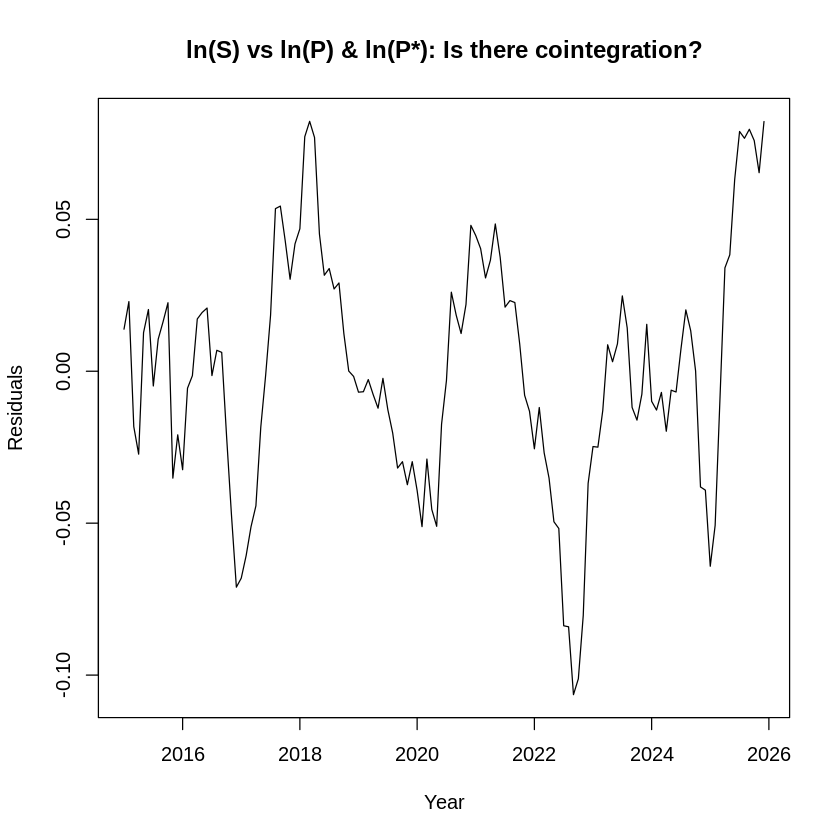

In [ ]:
ts.plot(residualtimeseries,
        main="ln(S) vs ln(P) & ln(P*): Is there cointegration?",
        xlab="Year", ylab="Residuals")

# Step 5: ADF test on residuals (Engle-Granger test)

In [ ]:
adf.test(residualtimeseries)


	Augmented Dickey-Fuller Test

data:  residualtimeseries
Dickey-Fuller = -2.858, Lag order = 5, p-value = 0.2197
alternative hypothesis: stationary


# NOTE: Use Engle-Yoo (1987) critical values, not standard DF values
# For 3 variables, the 5% Engle-Yoo critical value is approx -3.37

# Step 6: Test strict PPP restrictions
# Testing H0: B1 = 1

In [ ]:
coefs <- summary(Engle)$coefficients
B1 <- coefs["log_cpi_ireland", "Estimate"]
SE_B1 <- coefs["log_cpi_ireland", "Std. Error"]
t_B1 <- (B1 - 1) / SE_B1
cat("\nTest H0: B1 = 1\n")
cat("B1 =", round(B1, 4), ", SE =", round(SE_B1, 4), "\n")
cat("t-statistic = (B1 - 1) / SE(B1) =", round(t_B1, 4), "\n")
cat("p-value =", round(2*pt(abs(t_B1), df=Engle$df.residual, lower.tail=FALSE), 4), "\n")


Test H0: B1 = 1
B1 = -1.0344 , SE = 0.1902 
t-statistic = (B1 - 1) / SE(B1) = -10.6945 
p-value = 0 


# Testing H0: B2 = -1

In [ ]:
B2 <- coefs["log_cpi_usa", "Estimate"]
SE_B2 <- coefs["log_cpi_usa", "Std. Error"]
t_B2 <- (B2 - (-1)) / SE_B2
cat("\nTest H0: B2 = -1\n")
cat("B2 =", round(B2, 4), ", SE =", round(SE_B2, 4), "\n")
cat("t-statistic = (B2 - (-1)) / SE(B2) =", round(t_B2, 4), "\n")
cat("p-value =", round(2*pt(abs(t_B2), df=Engle$df.residual, lower.tail=FALSE), 4), "\n")


Test H0: B2 = -1
B2 = 0.6068 , SE = 0.1376 
t-statistic = (B2 - (-1)) / SE(B2) = 11.6788 
p-value = 0 


# PART F: Testing Relative PPP

In [ ]:
cat("\n=== PART F: Relative PPP - OLS on First Differences ===\n\n")


=== PART F: Relative PPP - OLS on First Differences ===



# Step 1: Create first differences

In [ ]:
diff_log_ner <- diff(df$log_ner)
diff_log_cpi_ire <- diff(df$log_cpi_ireland)
diff_log_cpi_usa <- diff(df$log_cpi_usa)

# Step 2: Construct inflation differential

In [ ]:
infl_diff <- diff_log_cpi_ire - diff_log_cpi_usa

# Confirm stationarity of differenced series

In [ ]:
cat("Confirming stationarity of differenced series:\n")
adf.test(ts(diff_log_ner, start=c(2015,2), frequency=12))
adf.test(ts(infl_diff, start=c(2015,2), frequency=12))


Confirming stationarity of differenced series:


Warning message in adf.test(ts(diff_log_ner, start = c(2015, 2), frequency = 12)):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts(diff_log_ner, start = c(2015, 2), frequency = 12)
Dickey-Fuller = -4.5971, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


Warning message in adf.test(ts(infl_diff, start = c(2015, 2), frequency = 12)):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts(infl_diff, start = c(2015, 2), frequency = 12)
Dickey-Fuller = -6.9143, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


# Step 3: Build dataframe for regression

In [ ]:
df_diff <- data.frame(
  d_log_ner = diff_log_ner,
  infl_diff = infl_diff
)

# Step 4: Run OLS: d_ln(S) = a + B*[d_ln(P) - d_ln(P*)] + e

In [ ]:
PPP_relative <- lm(d_log_ner ~ infl_diff, data=df_diff)
summary(PPP_relative)


Call:
lm(formula = d_log_ner ~ infl_diff, data = df_diff)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.054675 -0.009839 -0.001355  0.009979  0.045718 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.0001592  0.0015065   0.106    0.916
infl_diff   -0.1499524  0.2919903  -0.514    0.608

Residual standard error: 0.01703 on 129 degrees of freedom
Multiple R-squared:  0.00204,	Adjusted R-squared:  -0.005696 
F-statistic: 0.2637 on 1 and 129 DF,  p-value: 0.6084


# Step 5: Hypothesis Tests

# Test 1: H0: a = 0 (read from summary output directly)

In [ ]:
cat("\n--- Test 1: H0: alpha = 0 ---\n")
cat("Read the intercept p-value from summary() above.\n")
cat("If p-value > 0.05, cannot reject H0: intercept = 0\n\n")


--- Test 1: H0: alpha = 0 ---
Read the intercept p-value from summary() above.
If p-value > 0.05, cannot reject H0: intercept = 0



# Test 2: H0: B = 1 (manual t-test as per CLRM slides)

In [ ]:
cat("--- Test 2: H0: beta = 1 ---\n")
coefs_f <- summary(PPP_relative)$coefficients
B_hat <- coefs_f["infl_diff", "Estimate"]
SE_B <- coefs_f["infl_diff", "Std. Error"]
t_stat_B1 <- (B_hat - 1) / SE_B
df_f <- PPP_relative$df.residual
p_val_B1 <- 2 * pt(abs(t_stat_B1), df=df_f, lower.tail=FALSE)


--- Test 2: H0: beta = 1 ---


In [ ]:
cat("Beta =", round(B_hat, 6), ", SE =", round(SE_B, 6), "\n")
cat("t-statistic = (Beta - 1) / SE(Beta) =", round(t_stat_B1, 4), "\n")
cat("Degrees of freedom =", df_f, "\n")
cat("p-value =", round(p_val_B1, 4), "\n")
if (p_val_B1 > 0.05) {
  cat("Cannot reject H0: Beta is NOT significantly different from 1\n\n")
} else {
  cat("Reject H0: Beta IS significantly different from 1\n\n")
}

Beta = -0.149952 , SE = 0.29199 
t-statistic = (Beta - 1) / SE(Beta) = -3.9383 
Degrees of freedom = 129 
p-value = 1e-04 
Reject H0: Beta IS significantly different from 1



# Test 3: Joint F-test: H0: a = 0 AND B = 1

In [ ]:
cat("--- Test 3: Joint F-test: H0: alpha = 0 AND beta = 1 ---\n")
# Restricted model: d_ln(S) = infl_diff + e (no intercept, slope=1)
# Under restriction, residuals = d_log_ner - infl_diff
restricted_resid <- df_diff$d_log_ner - df_diff$infl_diff
RSS_r <- sum(restricted_resid^2)
RSS_u <- sum(PPP_relative$residuals^2)
n_obs <- nrow(df_diff)
q <- 2  # number of restrictions
k <- 2  # parameters in unrestricted model
F_stat <- ((RSS_r - RSS_u) / q) / (RSS_u / (n_obs - k))
p_val_F <- 1 - pf(F_stat, q, n_obs - k)

cat("RSS(restricted) =", round(RSS_r, 6), "\n")
cat("RSS(unrestricted) =", round(RSS_u, 6), "\n")
cat("F-statistic =", round(F_stat, 4), "\n")
cat("p-value =", round(p_val_F, 4), "\n")
if (p_val_F > 0.05) {
  cat("Cannot reject H0: both alpha=0 and beta=1 hold jointly\n")
} else {
  cat("Reject H0: the joint restriction alpha=0 and beta=1 does NOT hold\n")
}

--- Test 3: Joint F-test: H0: alpha = 0 AND beta = 1 ---
RSS(restricted) = 0.042082 
RSS(unrestricted) = 0.037428 
F-statistic = 8.0193 
p-value = 5e-04 
Reject H0: the joint restriction alpha=0 and beta=1 does NOT hold


#PART G: Box-Jenkins Modelling and Forecasting of the Real Exchange Rate (RER) - Ireland vs USA (2015-2025)

##**Step-1: Load Required Libraries**
###### forecast: provides auto.arima(), Arima(), forecast(), checkresiduals()
###### tseries:  provides adf.test() for stationarity confirmation
###### ggplot2:  for high-quality publication-ready plots
###### gridExtra: arranges multiple ggplots on one page
###### lmtest:   provides coeftest() for robust coefficient testing
###### urca:     provides ur.df() and ur.kpss() for unit root tests

In [ ]:
packages_needed <- c("forecast", "tseries", "ggplot2", "gridExtra", "lmtest", "urca")

for (pkg in packages_needed) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cran.rstudio.com/")
  }
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(forecast)   # ARIMA modelling, auto.arima(), forecast(), checkresiduals()
library(tseries)    # adf.test(), kpss.test() for stationarity tests
library(ggplot2)    # High-quality plots
library(gridExtra)  # Arrange multiple ggplots side by side
library(lmtest)     # coeftest() for coefficient significance tests
library(urca)       # ur.df() and ur.kpss() for advanced unit root tests


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




##**Step-2: Load and Prepare the Data**

In [ ]:
str(df)
head(df)

'data.frame':	132 obs. of  10 variables:
 $ date           : chr  "2015-01" "2015-02" "2015-03" "2015-04" ...
 $ cpi_ireland    : num  98.7 99.3 100 99.9 100.4 ...
 $ cpi_usa        : num  99 99.3 99.6 99.7 100 ...
 $ ner            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ rer            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ log_ner        : num  0.1214 0.1258 0.079 0.0716 0.1084 ...
 $ log_rer        : num  0.125 0.1258 0.0746 0.0692 0.1045 ...
 $ log_cpi_ireland: num  4.59 4.6 4.61 4.6 4.61 ...
 $ log_cpi_usa    : num  4.6 4.6 4.6 4.6 4.61 ...
 $ date_obj       : Date, format: "2015-01-01" "2015-02-01" ...


,date,cpi_ireland,cpi_usa,ner,rer,log_ner,log_rer,log_cpi_ireland,log_cpi_usa,date_obj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
1,2015-01,98.7,99.05,1.1291,1.1331,0.12142086,0.12495724,4.592085,4.595625,2015-01-01
2,2015-02,99.3,99.30,1.1340,1.1340,0.12575121,0.12575121,4.598146,4.598146,2015-02-01
3,2015-03,100.0,99.57,1.0822,1.0775,0.07899601,0.07464354,4.605170,4.600861,2015-03-01
4,2015-04,99.9,99.67,1.0742,1.0717,0.07157620,0.06924617,4.604170,4.601865,2015-04-01
5,2015-05,100.4,100.00,1.1145,1.1101,0.10840587,0.10445010,4.609162,4.605170,2015-05-01
6,2015-06,100.8,100.28,1.1203,1.1145,0.11359651,0.10840587,4.613138,4.607966,2015-06-01


In [ ]:
# Read the merged dataset that contains monthly CPI, exchange rate data & log variables
df <- read.csv(file_path, stringsAsFactors = FALSE)


In [ ]:
str(df)

'data.frame':	132 obs. of  10 variables:
 $ date           : chr  "2015-01" "2015-02" "2015-03" "2015-04" ...
 $ cpi_ireland    : num  98.7 99.3 100 99.9 100.4 ...
 $ cpi_usa        : num  99 99.3 99.6 99.7 100 ...
 $ ner            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ rer            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ log_ner        : num  0.1214 0.1258 0.079 0.0716 0.1084 ...
 $ log_rer        : num  0.125 0.1258 0.0746 0.0692 0.1045 ...
 $ log_cpi_ireland: num  4.59 4.6 4.61 4.6 4.61 ...
 $ log_cpi_usa    : num  4.6 4.6 4.6 4.6 4.61 ...
 $ date_obj       : chr  "2015-01-01" "2015-02-01" "2015-03-01" "2015-04-01" ...


In [ ]:
df$date_obj <- as.Date(df$date_obj, format = "%Y-%m-%d")

In [ ]:
str(df)

'data.frame':	132 obs. of  10 variables:
 $ date           : chr  "2015-01" "2015-02" "2015-03" "2015-04" ...
 $ cpi_ireland    : num  98.7 99.3 100 99.9 100.4 ...
 $ cpi_usa        : num  99 99.3 99.6 99.7 100 ...
 $ ner            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ rer            : num  1.13 1.13 1.08 1.07 1.11 ...
 $ log_ner        : num  0.1214 0.1258 0.079 0.0716 0.1084 ...
 $ log_rer        : num  0.125 0.1258 0.0746 0.0692 0.1045 ...
 $ log_cpi_ireland: num  4.59 4.6 4.61 4.6 4.61 ...
 $ log_cpi_usa    : num  4.6 4.6 4.6 4.6 4.61 ...
 $ date_obj       : Date, format: "2015-01-01" "2015-02-01" ...


In [ ]:
# Quick sanity check: print first and last rows
cat("\nData Loaded Successfully\n")
cat("Rows:", nrow(df), "| Columns:", ncol(df), "\n")
cat("Date range:", format(min(df$date_obj), "%b %Y"),
    "to", format(max(df$date_obj), "%b %Y"), "\n")
cat("Columns:", paste(names(df), collapse = ", "), "\n")
cat("Missing values:", sum(is.na(df)), "\n\n")


Data Loaded Successfully
Rows: 132 | Columns: 10 
Date range: Jan 2015 to Dec 2025 
Columns: date, cpi_ireland, cpi_usa, ner, rer, log_ner, log_rer, log_cpi_ireland, log_cpi_usa, date_obj 
Missing values: 0 



##**STEP-3: Create Time Series Objects**

In [ ]:
# Converting log_rer into a ts (time series) object.

rer_ts <- ts(df$log_rer,
             start     = c(2015, 1), #series begins January 2015
             frequency = 12)         #12 observations per year

cat("Time Series Object Created: \n")
cat("Length:", length(rer_ts), "monthly observations\n")
cat("Start:", tsp(rer_ts)[1], "| End:", tsp(rer_ts)[2], "\n")
cat("Mean log(RER):", round(mean(rer_ts), 4), "\n")
cat("Std Dev log(RER):", round(sd(rer_ts), 4), "\n\n")


Time Series Object Created: 
Length: 132 monthly observations
Start: 2015 | End: 2025.917 
Mean log(RER): 0.1784 
Std Dev log(RER): 0.0574 



##**STEP-4: BOX JENKINS Modelling - Identification**

Stationarity Tests: 

1. ADF Test: log(RER) in Levels: 

	Augmented Dickey-Fuller Test

data:  rer_ts
Dickey-Fuller = -2.4983, Lag order = 5, p-value = 0.3693
alternative hypothesis: stationary


 2. KPSS Test: log(RER) in Levels: 


Warning message in kpss.test(rer_ts, null = "Level"):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  rer_ts
KPSS Level = 0.74398, Truncation lag parameter = 4, p-value = 0.01


ADF Test: delta(log(RER)) — First Difference: 


Warning message in adf.test(rer_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  rer_diff
Dickey-Fuller = -4.552, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary


KPSS Test: delta(log(RER)) — First Difference: 


Warning message in kpss.test(rer_diff, null = "Level"):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  rer_diff
KPSS Level = 0.054495, Truncation lag parameter = 4, p-value = 0.1


Conclusion: log(RER) is I(1) -> use d = 1 in all ARIMA models



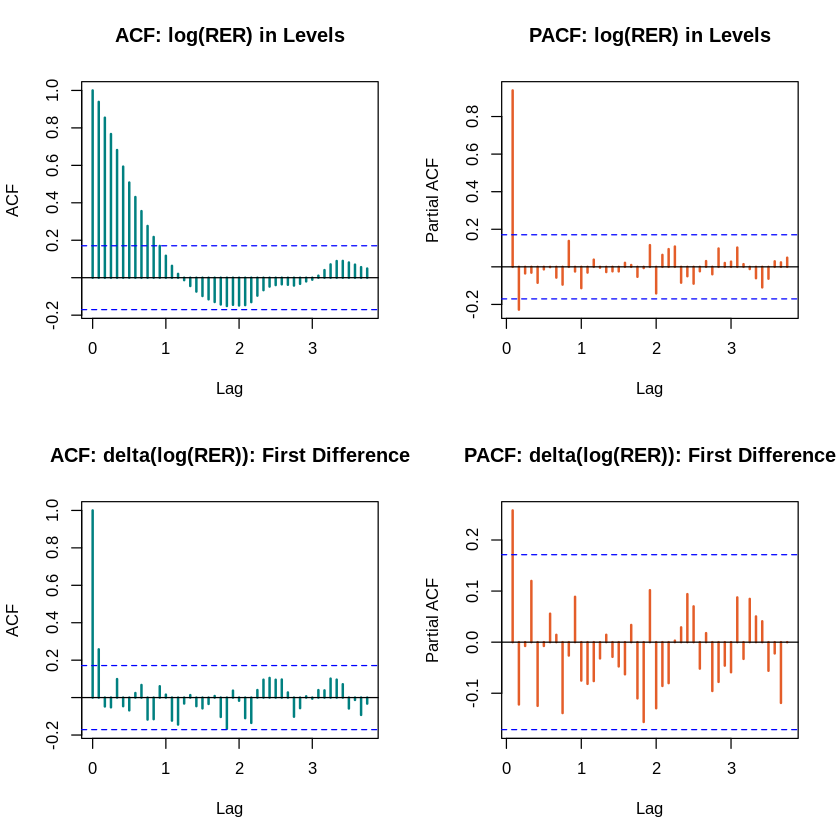

In [ ]:
# Before Box-Jenkins, we must confirm the order of integration d.
# From Section 4.7 of the report, we expect log(RER) to be I(1).

cat("Stationarity Tests: \n\n")


cat("1. ADF Test: log(RER) in Levels: \n") #ADF Test on LEVEL series.
adf_level <- adf.test(rer_ts)
print(adf_level) #Expect Failure to reject (p > 0.05) → non-stationary in levels.


cat("\n 2. KPSS Test: log(RER) in Levels: \n") #KPSS Test on LEVEL series.
kpss_level <- kpss.test(rer_ts, null = "Level")
print(kpss_level) # Expect reject (p < 0.05) -> consistent with non-stationarity.

rer_diff <- diff(rer_ts) #First difference the series - represents the monthly percentage change in the real exchange rate.


cat("\nADF Test: delta(log(RER)) — First Difference: \n") #ADF Test on First Difference.
adf_diff <- adf.test(rer_diff)
print(adf_diff) #Expect Reject (p < 0.05) -> stationary after differencing -> d = 1 confirmed.


cat("\nKPSS Test: delta(log(RER)) — First Difference: \n") #KPSS Test on First Difference.
kpss_diff <- kpss.test(rer_diff, null = "Level")
print(kpss_diff) # Expect Failure to reject (p > 0.05) -> stationary -> confirms d = 1

cat("\nConclusion: log(RER) is I(1) -> use d = 1 in all ARIMA models\n\n")


par(mfrow = c(2, 2))   # 2×2 grid for 4 plots

# Plot ACF of the LEVEL series (shows non-stationarity via slow decay)
acf(rer_ts,
    lag.max = 45,
    main    = "ACF: log(RER) in Levels",
    col     = "#008080",
    lwd     = 2)

# Plot PACF of the LEVEL series
pacf(rer_ts,
     lag.max = 45,
     main    = "PACF: log(RER) in Levels",
     col     = "#e45d29",
     lwd     = 2)

# Plot ACF of the Differenced series (what we actually use for model ID)
acf(rer_diff,
    lag.max = 45,
    main    = "ACF: delta(log(RER)): First Difference",
    col     = "#008080",
    lwd     = 2)

# Plot PACF of the Differenced series
pacf(rer_diff,
     lag.max = 45,
     main    = "PACF: delta(log(RER)): First Difference",
     col     = "#e45d29",
     lwd     = 2)

par(mfrow = c(1, 1))   # Reset plot layout to single

##**STEP-5: BOX JENKINS Modelling - Estimation (8 ARIMA Models)**

In [ ]:
#Checking if the object is present:
print(head(rer_ts))

            Jan        Feb        Mar        Apr        May        Jun
2015 0.12495724 0.12575121 0.07464354 0.06924617 0.10445010 0.10840587


In [ ]:
#Importing libraries for visualisation:
theme_ec6011 <- theme_minimal(base_size = 11) +
  theme(
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(colour = "grey40", size = 10),
    plot.caption     = element_text(colour = "grey50", size = 8),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey92"),
    axis.title       = element_text(size = 10),
    legend.position  = "bottom",
    legend.title     = element_blank()
  )

##### **Model 1: ARIMA (0,1,0)**

In [ ]:
cat("Estimation of ARIMA Models \n\n ")

m1 <- Arima(rer_ts, order = c(0, 1, 0), method = "ML") # Model 1: ARIMA(0,1,0) — Pure Random Walk (Benchmark)
cat("Model 1: ARIMA(0,1,0) Random Walk: \n ")
print(summary(m1))

Estimation of ARIMA Models 

 Model 1: ARIMA(0,1,0) Random Walk: 
 Series: rer_ts 
ARIMA(0,1,0) 

sigma^2 = 0.0003211:  log likelihood = 340.98
AIC=-679.96   AICc=-679.92   BIC=-677.08

Training set error measures:
                      ME       RMSE        MAE        MPE     MAPE     MASE
Training set 0.001074473 0.01785229 0.01392372 -0.2789696 9.188371 0.246632
                 ACF1
Training set 0.257846


##### **Model 2: ARIMA (1,1,0)**

In [ ]:
m2 <- Arima(rer_ts, order = c(1, 1, 0), method = "ML") #Model 2: ARIMA(1,1,0) — AR(1) in differences. Thi tests whether last month's exchange rate change predicts this month's rate.
cat("\nModel 2: ARIMA(1,1,0):\n ")
print(summary(m2))



Model 2: ARIMA(1,1,0):
 Series: rer_ts 
ARIMA(1,1,0) 

Coefficients:
         ar1
      0.2589
s.e.  0.0841

sigma^2 = 0.0003016:  log likelihood = 345.55
AIC=-687.1   AICc=-687.01   BIC=-681.35

Training set error measures:
                       ME       RMSE        MAE        MPE     MAPE      MASE
Training set 0.0008157686 0.01723542 0.01334623 -0.1410384 8.960074 0.2364028
                   ACF1
Training set 0.03075184


##### **Model 3: ARIMA (0,1,1)**

In [ ]:
m3 <- Arima(rer_ts, order = c(0, 1, 1), method = "ML") #Model 3: ARIMA(0,1,1) - MA(1) in differences: One moving average lag: current change depends on last month's shock.
cat("\nModel 3: ARIMA(0,1,1):\n ")
print(summary(m3))


Model 3: ARIMA(0,1,1):
 Series: rer_ts 
ARIMA(0,1,1) 

Coefficients:
        ma1
      0.286
s.e.  0.080

sigma^2 = 0.0002986:  log likelihood = 346.2
AIC=-688.41   AICc=-688.31   BIC=-682.66

Training set error measures:
                       ME       RMSE        MAE        MPE     MAPE      MASE
Training set 0.0008526896 0.01714853 0.01329857 -0.1441573 8.936198 0.2355586
                     ACF1
Training set 0.0007740373


##### **Model 4: ARIMA (1,1,1)**

In [ ]:
m4 <- Arima(rer_ts, order = c(1, 1, 1), method = "ML") #Model 4: ARIMA(1,1,1):Combines AR(1) and MA(1): captures both momentum and shock effects
cat("\nModel 4: ARIMA(1,1,1):\n")
print(summary(m4))


Model 4: ARIMA(1,1,1):
Series: rer_ts 
ARIMA(1,1,1) 

Coefficients:
         ar1     ma1
      0.0155  0.2727
s.e.  0.2216  0.2055

sigma^2 = 0.0003009:  log likelihood = 346.21
AIC=-686.41   AICc=-686.22   BIC=-677.79

Training set error measures:
                       ME       RMSE        MAE        MPE     MAPE      MASE
Training set 0.0008487191 0.01714817 0.01329715 -0.1422313 8.937477 0.2355335
                      ACF1
Training set -0.0009022164


##### **Model 5: ARIMA (2,1,0)**

In [ ]:
m5 <- Arima(rer_ts, order = c(2, 1, 0), method = "ML") #Model 5: ARIMA(2,1,0): AR(2) in differences - Tests whether a slightly longer memory process fits better.
cat("\nModel 5: ARIMA(2,1,0): \n")
print(summary(m5))



Model 5: ARIMA(2,1,0): 
Series: rer_ts 
ARIMA(2,1,0) 

Coefficients:
         ar1      ar2
      0.2922  -0.1258
s.e.  0.0868   0.0892

sigma^2 = 0.0002994:  log likelihood = 346.54
AIC=-687.07   AICc=-686.88   BIC=-678.45

Training set error measures:
                       ME       RMSE        MAE        MPE     MAPE      MASE
Training set 0.0009146519 0.01710401 0.01332045 -0.1480275 8.953081 0.2359463
                     ACF1
Training set -0.003189839


##### **Model 6: ARIMA (0,1,2)**

In [ ]:
m6 <- Arima(rer_ts, order = c(0, 1, 2), method = "ML") #Model 6: ARIMA(0,1,2): MA(2) in differences. This shows shocks from two months ago still influence today.
cat("\nModel 6: ARIMA(0,1,2):\n")
print(summary(m6))


Model 6: ARIMA(0,1,2):
Series: rer_ts 
ARIMA(0,1,2) 

Coefficients:
         ma1     ma2
      0.2902  0.0080
s.e.  0.0928  0.0853

sigma^2 = 0.0003009:  log likelihood = 346.21
AIC=-686.42   AICc=-686.23   BIC=-677.79

Training set error measures:
                       ME       RMSE        MAE        MPE     MAPE      MASE
Training set 0.0008455753 0.01714787 0.01329606 -0.1406098 8.938683 0.2355141
                     ACF1
Training set -0.002441545


##### **Model 7: ARIMA (2,1,2)**

In [ ]:
m7 <- Arima(rer_ts, order = c(2, 1, 2), method = "ML") #Model 7: ARIMA(2,1,2) — General ARMA(2,2) in differences. Captures richer dynamics but risks overfitting with limited data.
cat("\nModel 7: ARIMA(2,1,2):\n")
print(summary(m7))


Model 7: ARIMA(2,1,2):
Series: rer_ts 
ARIMA(2,1,2) 

Coefficients:
          ar1      ar2     ma1     ma2
      -0.4354  -0.7442  0.6937  0.8367
s.e.   0.1391   0.1097  0.1052  0.1180

sigma^2 = 0.000289:  log likelihood = 349.56
AIC=-689.12   AICc=-688.64   BIC=-674.75

Training set error measures:
                       ME       RMSE        MAE        MPE    MAPE      MASE
Training set 0.0009584358 0.01667626 0.01335171 -0.1152111 8.80701 0.2364999
                   ACF1
Training set 0.05204039


##### **Model 8: auto.arima()**

In [ ]:
cat("\nModel 8: auto.arima() (searching over all combinations): \n") #auto.arima() — Data-Driven Automated Selection This gives us the statistically optimal model.
m8 <- auto.arima(rer_ts,
                 stepwise     = FALSE, #checks ALL combinations (slower but thorough).
                 approximation = FALSE, #uses exact likelihood (more accurate).
                 ic           = "aic",
                 trace        = TRUE)   #trace=TRUE prints each model tried.
print(summary(m8))


Model 8: auto.arima() (searching over all combinations): 

 ARIMA(0,1,0)                               : -679.9553
 ARIMA(0,1,0)            with drift         : -678.4335
 ARIMA(0,1,0)(0,0,1)[12]                    : -678.0055
 ARIMA(0,1,0)(0,0,1)[12] with drift         : -676.4741
 ARIMA(0,1,0)(0,0,2)[12]                    : -676.0312
 ARIMA(0,1,0)(0,0,2)[12] with drift         : -674.5138
 ARIMA(0,1,0)(1,0,0)[12]                    : -678.0039
 ARIMA(0,1,0)(1,0,0)[12] with drift         : -676.4725
 ARIMA(0,1,0)(1,0,1)[12]                    : Inf
 ARIMA(0,1,0)(1,0,1)[12] with drift         : Inf
 ARIMA(0,1,0)(1,0,2)[12]                    : -674.0294
 ARIMA(0,1,0)(1,0,2)[12] with drift         : -672.5101
 ARIMA(0,1,0)(2,0,0)[12]                    : -676.0344
 ARIMA(0,1,0)(2,0,0)[12] with drift         : -674.5178
 ARIMA(0,1,0)(2,0,1)[12]                    : -674.035
 ARIMA(0,1,0)(2,0,1)[12] with drift         : -672.5168
 ARIMA(0,1,0)(2,0,2)[12]                    : Inf
 ARIMA(

#####**Model Comparison Table**

In [ ]:
models_list  <- list(m1, m2, m3, m4, m5, m6, m7, m8)
model_labels <- c("ARIMA(0,1,0)", "ARIMA(1,1,0)", "ARIMA(0,1,1)", "ARIMA(1,1,1)", "ARIMA(2,1,0)", "ARIMA(0,1,2)", "ARIMA(2,1,2)", "Auto ARIMA")

cat("All 8 models estimated successfully!\n")


All 8 models estimated successfully!


In [ ]:
cat("\nMODEL COMPARISON TABLE: \n\n")

# Extract metrics for each model using sapply:
aic_vals  <- sapply(models_list, AIC)
bic_vals  <- sapply(models_list, BIC)
rmse_vals <- sapply(models_list, function(m) round(sqrt(mean(residuals(m)^2)), 6))

# Ljung-Box p-value at lag 12: tests for remaining autocorrelation - p > 0.05 means residuals are white noise (good)
lb_pvals <- sapply(seq_along(models_list), function(i) {
  m   <- models_list[[i]]
  npar <- length(m$coef)   # number of estimated parameters in this model
  round(Box.test(residuals(m), lag = 12,
                 type = "Ljung-Box", fitdf = npar)$p.value, 4)
})

out_table <- data.frame(
  Model    = model_labels,
  AIC      = round(aic_vals,  2),
  BIC      = round(bic_vals,  2),
  RMSE     = round(rmse_vals, 6),
  LB_p12   = round(lb_pvals,  4),
  LB_Pass  = ifelse(lb_pvals >= 0.06, "Yes", "No"),
  stringsAsFactors = FALSE
)

print(out_table)

# Identify best model by AIC
best_idx   <- which.min(aic_vals)
best_model <- models_list[[best_idx]]
best_label <- model_labels[[best_idx]]
cat("\n Best model by AIC:", best_label,
    "| AIC =", round(aic_vals[best_idx], 2),
    "| BIC =", round(bic_vals[best_idx], 2), "\n\n")




MODEL COMPARISON TABLE: 

         Model     AIC     BIC     RMSE LB_p12 LB_Pass
1 ARIMA(0,1,0) -679.96 -677.08 0.017852 0.1464     Yes
2 ARIMA(1,1,0) -687.10 -681.35 0.017235 0.2562     Yes
3 ARIMA(0,1,1) -688.41 -682.66 0.017149 0.4854     Yes
4 ARIMA(1,1,1) -686.41 -677.79 0.017148 0.3883     Yes
5 ARIMA(2,1,0) -687.07 -678.45 0.017104 0.4978     Yes
6 ARIMA(0,1,2) -686.42 -677.79 0.017148 0.3812     Yes
7 ARIMA(2,1,2) -689.12 -674.75 0.016676 0.8531     Yes
8   Auto ARIMA -689.12 -674.75 0.016676 0.8531     Yes

 Best model by AIC: Auto ARIMA | AIC = -689.12 | BIC = -674.75 



In [ ]:
# Create comp_df from out_table
comp_df <- out_table[, c("Model", "RMSE")]

# Mark best model(s) based on RMSE
comp_df$Best <- ifelse(comp_df$RMSE == min(comp_df$RMSE), "Best", "Other")

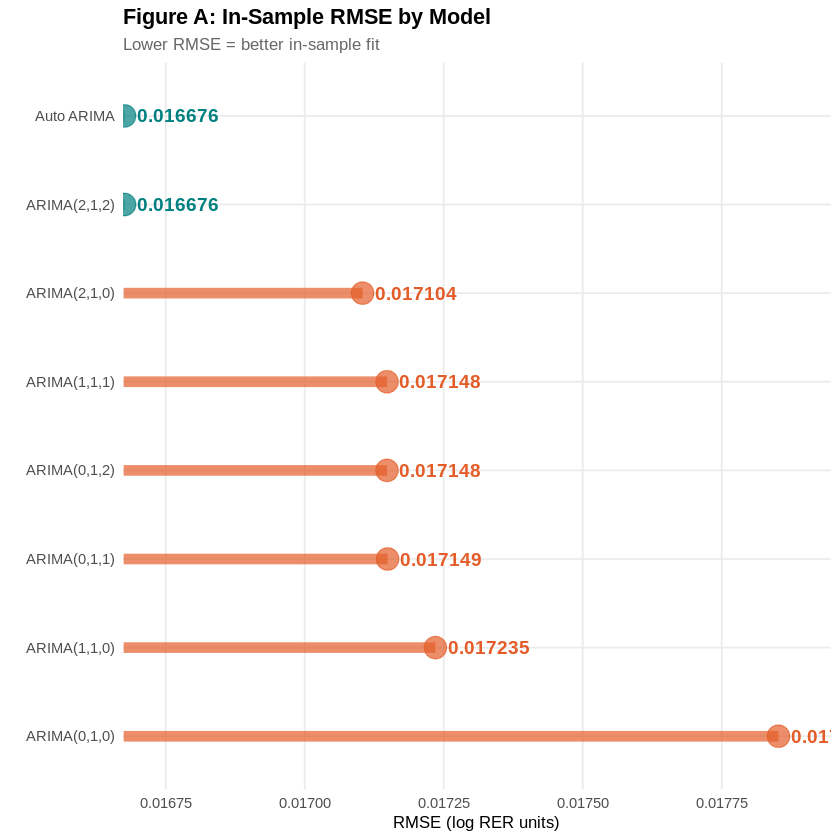

In [ ]:
# Shared theme — consistent with rest of your notebook
theme_ec6011 <- theme_minimal(base_size = 11) +
  theme(
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(colour = "grey40", size = 10),
    plot.caption     = element_text(colour = "grey50", size = 8),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey92"),
    axis.title       = element_text(size = 10),
    legend.position  = "bottom",
    legend.title     = element_blank()
  )

# Purpose: RMSE captures in-sample fit on the original scale.

p_rmse <- ggplot(comp_df, aes(x = reorder(Model, -RMSE), y = RMSE,
                               colour = Best)) +
  geom_point(size = 6, alpha = 0.7) +
  geom_segment(aes(xend = reorder(Model, -RMSE), y = min(RMSE)*0.9999,
                   yend = RMSE), linewidth = 3, alpha = 0.7) +
  geom_text(aes(label = formatC(RMSE, format="f", digits=6)),
            hjust = -0.15, size = 4, fontface = "bold") +
  scale_colour_manual(values = c("Best" = "#008080", "Other" = "#e45d29"),
                      guide = "none") +

scale_y_continuous(expand = expansion(mult = c(0.001, 0.08))) +
  coord_flip() +
  labs(title    = "Figure A: In-Sample RMSE by Model",
       subtitle = "Lower RMSE = better in-sample fit",
       x = NULL, y = "RMSE (log RER units)") +
  theme_ec6011

print(p_rmse)


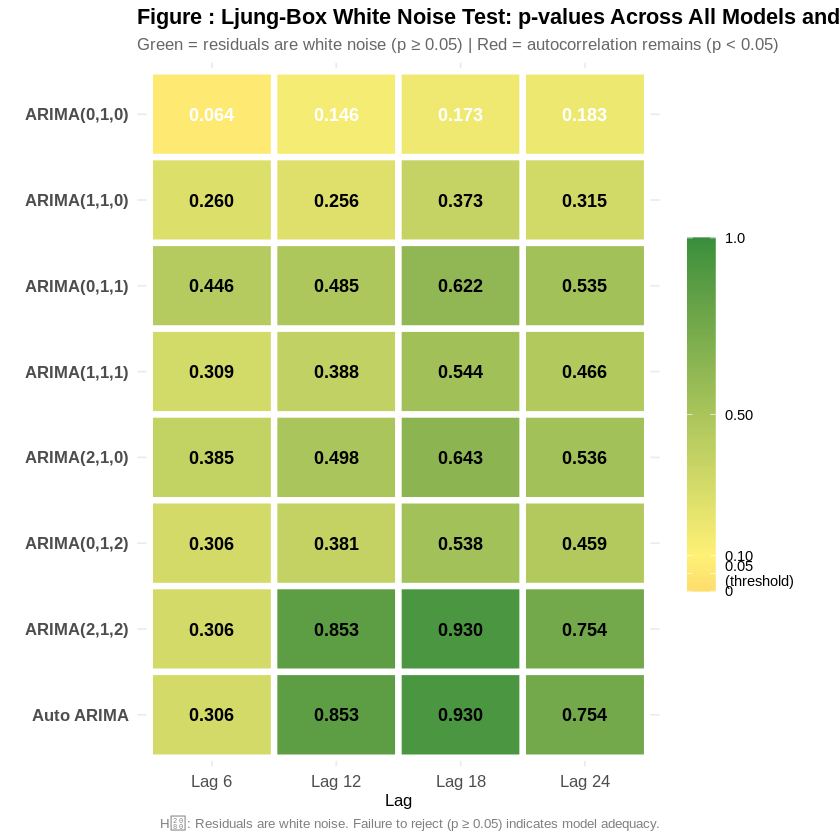

In [ ]:
# Ljung-Box Heatmap + Normalised Scorecard
# Shared theme: consistent with rest of your notebook
theme_ec6011 <- theme_minimal(base_size = 11) +
  theme(
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(colour = "grey40", size = 10),
    plot.caption     = element_text(colour = "grey50", size = 8),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey92"),
    axis.title       = element_text(size = 10),
    legend.position  = "bottom",
    legend.title     = element_blank()
  )


lags_to_test <- c(6, 12, 18, 24)

# Build matrix of p-values: one row per model, one column per lag
lb_matrix <- matrix(
  NA,
  nrow     = length(models_list),
  ncol     = length(lags_to_test),
  dimnames = list(model_labels, paste0("Lag ", lags_to_test))
)

for (i in seq_along(models_list)) {
  npar <- length(models_list[[i]]$coef)   # number of estimated parameters
  for (j in seq_along(lags_to_test)) {
    lb_matrix[i, j] <- Box.test(
      residuals(models_list[[i]]),
      lag   = lags_to_test[j],
      type  = "Ljung-Box",
      fitdf = npar          # subtract estimated params from degrees of freedom
    )$p.value
  }
}

# Convert matrix to long format for ggplot
lb_long <- melt(lb_matrix,
                varnames   = c("Model", "Lag"),
                value.name = "pvalue")

# Fix factor ordering so models appear top-to-bottom as listed
lb_long$Model <- factor(lb_long$Model, levels = rev(model_labels))

# Label each cell as Pass or Fail for the colour scale midpoint
lb_long$Label <- round(lb_long$pvalue, 3)

p_lb_heat <- ggplot(lb_long, aes(x = Lag, y = Model, fill = pvalue)) +

  # Coloured tile per cell
  geom_tile(colour = "white", linewidth = 1.8) +

  # p-value label inside each cell
  # White text on dark (red) cells, black text on light (green) cells
  geom_text(
    aes(label  = sprintf("%.3f", pvalue),
        colour = ifelse(pvalue > 0.20, "black", "white")),
    size      = 3.8,
    fontface  = "bold"
  ) +

  # Colour scale: red (fail) → yellow (borderline) → green (pass)
  scale_fill_gradient2(
    low      = "#D32F2F",   # strong red for p near 0
    mid      = "#FFF176",   # yellow for borderline
    high     = "#388E3C",   # strong green for p near 1
    midpoint = 0.10,
    limits   = c(0, 1),
    name     = "p-value",
    breaks   = c(0, 0.05, 0.10, 0.50, 1.0),
    labels   = c("0", "0.05\n(threshold)", "0.10", "0.50", "1.0")
  ) +

  scale_colour_identity() +   # uses the ifelse colour directly

  # Add a horizontal reference line at the 0.05 threshold
  geom_hline(yintercept = seq(0.5, length(model_labels) - 0.5, 1),
             colour = "white", linewidth = 0.3) +

  labs(
    title    = "Figure : Ljung-Box White Noise Test: p-values Across All Models and Lags",
    subtitle = "Green = residuals are white noise (p ≥ 0.05) | Red = autocorrelation remains (p < 0.05)",
    x        = "Lag",
    y        = NULL,
    caption  = "H₀: Residuals are white noise. Failure to reject (p ≥ 0.05) indicates model adequacy."
  ) +

  theme_ec6011 +
  theme(
    legend.position  = "right",
    legend.key.height = unit(1.5, "cm"),
    axis.text.y      = element_text(size = 10, face = "bold"),
    axis.text.x      = element_text(size = 10)
  )

print(p_lb_heat)





Overall Model Ranking (by average normalised score): 
        Model AIC_score BIC_score RMSE_score LB_score Overall
   Auto ARIMA     1.000     0.000      1.000    1.000   0.750
 ARIMA(2,1,2)     1.000     0.000      1.000    1.000   0.750
 ARIMA(0,1,1)     0.922     1.000      0.598    0.480   0.750
 ARIMA(2,1,0)     0.776     0.468      0.636    0.497   0.594
 ARIMA(1,1,0)     0.779     0.835      0.525    0.155   0.573
 ARIMA(1,1,1)     0.704     0.384      0.599    0.342   0.507
 ARIMA(0,1,2)     0.705     0.385      0.599    0.332   0.505
 ARIMA(0,1,0)     0.000     0.295      0.000    0.000   0.074


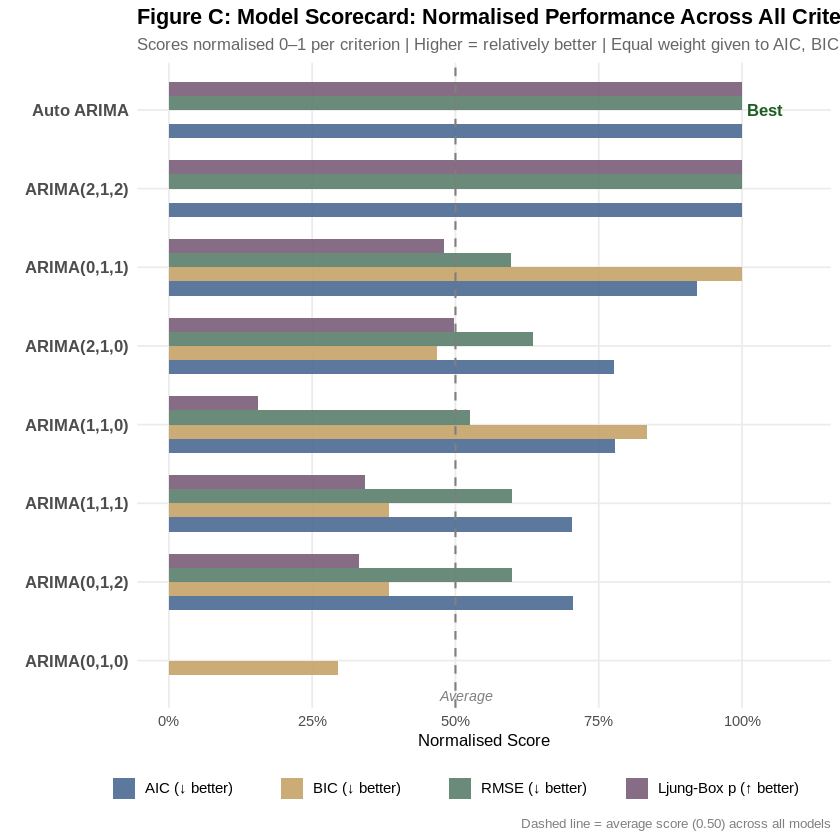

In [ ]:
# Normalised Model Scorecard
# Each criterion (AIC, BIC, RMSE, Ljung-Box) is normalised to 0–1 so all four are directly comparable on the same axis.
# Higher bar = relatively better performance on that criterion.


comp_df <- data.frame(
  Model = model_labels,
  AIC   = aic_vals,
  BIC   = bic_vals,
  RMSE  = rmse_vals,
  LB_p  = lb_pvals
)


normalise <- function(x) (x - min(x)) / (max(x) - min(x))

comp_df$AIC_score  <- 1 - normalise(comp_df$AIC)
comp_df$BIC_score  <- 1 - normalise(comp_df$BIC)
comp_df$RMSE_score <- 1 - normalise(comp_df$RMSE)
comp_df$LB_score   <- normalise(comp_df$LB_p)

# Overall score: equal weight across all four criteria
comp_df$Overall <- rowMeans(
  comp_df[, c("AIC_score", "BIC_score", "RMSE_score", "LB_score")]
)

# Melt to long format for grouped bar chart
score_long <- melt(
  comp_df[, c("Model", "AIC_score", "BIC_score", "RMSE_score", "LB_score")],
  id.vars      = "Model",
  variable.name = "Criterion",
  value.name   = "Score"
)

# Clean up criterion labels for the legend
score_long$Criterion <- factor(
  score_long$Criterion,
  levels = c("AIC_score", "BIC_score", "RMSE_score", "LB_score"),
  labels = c("AIC (↓ better)", "BIC (↓ better)",
             "RMSE (↓ better)", "Ljung-Box p (↑ better)")
)

# Order models by their overall score (best at top after coord_flip)
model_order <- comp_df$Model[order(comp_df$Overall)]
score_long$Model <- factor(score_long$Model, levels = model_order)

# Highlight the best overall model
best_overall <- comp_df$Model[which.max(comp_df$Overall)]
score_long$IsBest <- ifelse(score_long$Model == best_overall, "Best", "")

p_scorecard <- ggplot(score_long,
                      aes(x = Model, y = Score, fill = Criterion)) +

  geom_col(position = "dodge", width = 0.72, alpha = 0.90) +

  # Reference line at 0.5 — models scoring above this are above average
  geom_hline(yintercept = 0.5,
             linetype   = "dashed",
             colour     = "grey50",
             linewidth  = 0.6) +

  annotate("text",
           x = 0.55, y = 0.52,
           label    = "Average",
           size     = 3,
           colour   = "grey50",
           fontface = "italic") +

  # Star label above the best model
  annotate("text",
           x     = which(levels(score_long$Model) == best_overall),
           y     = 1.04,
           label = "Best",
           size  = 3.5,
           colour = "#1B5E20",
           fontface = "bold") +

#332288", "#88CCEE", "#44AA99","#117733", "#999933", "#DDCC77","#CC6677", "#882255", "#AA4499

  scale_fill_manual(
    values = c(
      "AIC (↓ better)"         = "#4C6A92",   # Steel Blue
    "BIC (↓ better)"         = "#C6A367",   # Muted Gold
    "RMSE (↓ better)"        = "#5A7D6C",   # Deep Sage
    "Ljung-Box p (↑ better)" = "#7A5C78"    # Muted Plum
    )
  ) +

  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    limits = c(0, 1.10),
    breaks = seq(0, 1, 0.25)
  ) +

  coord_flip() +

  labs(
    title    = "Figure C: Model Scorecard: Normalised Performance Across All Criteria",
    subtitle = paste("Scores normalised 0–1 per criterion | Higher = relatively better |",
                     "Equal weight given to AIC, BIC, RMSE, and Ljung-Box"),
    x        = NULL,
    y        = "Normalised Score",
    caption  = "Dashed line = average score (0.50) across all models"
  ) +

  theme_ec6011 +
  theme(
    legend.position  = "bottom",
    legend.key.size  = unit(0.5, "cm"),
    legend.text      = element_text(size = 9),
    axis.text.y      = element_text(size = 10, face = "bold")
  )

print(p_scorecard)

# Print the overall ranking as a table too
cat("\nOverall Model Ranking (by average normalised score): \n")
ranking <- comp_df[order(-comp_df$Overall),
                   c("Model","AIC_score","BIC_score","RMSE_score",
                     "LB_score","Overall")]
ranking[, 2:6] <- round(ranking[, 2:6], 3)
print(ranking, row.names = FALSE)

##**STEP-6: BOX JENKINS Modelling - Verification**

RESIDUAL DIAGNOSTICS: Auto ARIMA 


	Ljung-Box test

data:  Residuals from ARIMA(2,1,2)
Q* = 15.382, df = 20, p-value = 0.7541

Model df: 4.   Total lags used: 24


Ljung-Box Test at Multiple Lags (H0: residuals are white noise):
  Lag  6: Q =  2.368, p-value = 0.3060 White noise
  Lag 12: Q =  4.045, p-value = 0.8531 White noise
  Lag 18: Q =  7.115, p-value = 0.9302 White noise
  Lag 24: Q = 15.382, p-value = 0.7541 White noise

Shapiro-Wilk Normality Test:
  W = 0.9891, p-value = 0.3899 Normal residuals

Estimated Coefficients (with t-statistics):

z test of coefficients:

    Estimate Std. Error z value  Pr(>|z|)    
ar1 -0.43542    0.13905 -3.1314   0.00174 ** 
ar2 -0.74424    0.10966 -6.7867 1.147e-11 ***
ma1  0.69368    0.10520  6.5938 4.287e-11 ***
ma2  0.83671    0.11791  7.0964 1.280e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


LJUNG-BOX SUMMARY: ALL MODELS (lag = 12)
  ARIMA(0,1,0)     LB p = 0.1464  ✓
  ARIMA(1,1,0)     LB p = 0.2562  ✓
  ARI

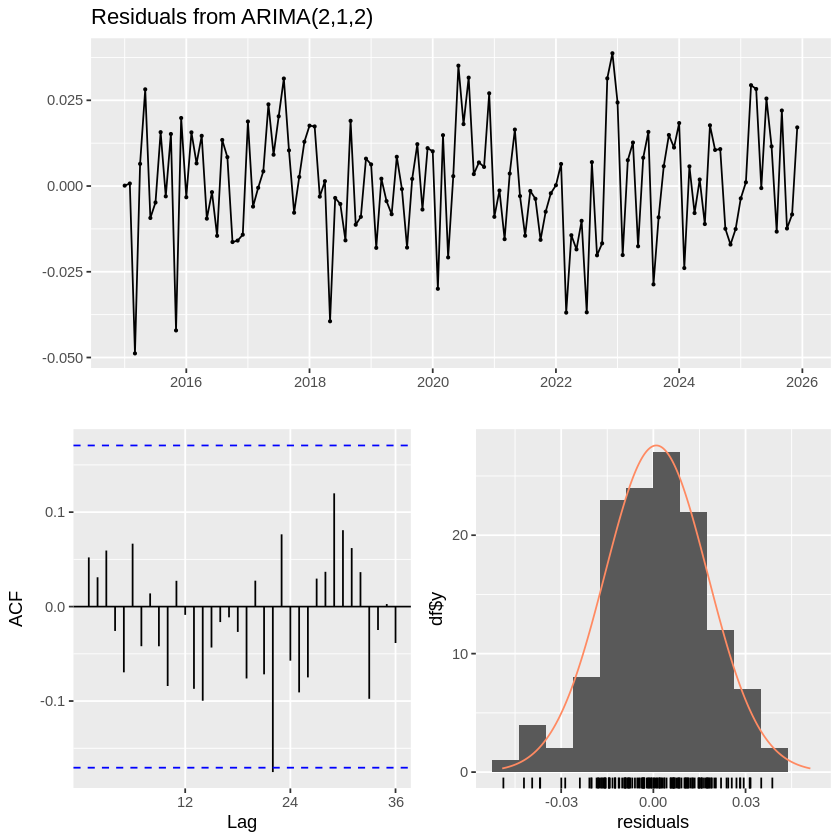

In [ ]:
#Box-Jenkins Diagnostic Stage on best model: residuals must be White noise.
# White noise = zero mean, constant variance, no autocorrelation, normal.

cat("RESIDUAL DIAGNOSTICS:", best_label, "\n\n")

checkresiduals(best_model) #plots residual time series

cat("\nLjung-Box Test at Multiple Lags (H0: residuals are white noise):\n")
for (lag_val in c(6, 12, 18, 24)) {
  npar <- length(best_model$coef)
  lb   <- Box.test(residuals(best_model), lag = lag_val,
                   type = "Ljung-Box", fitdf = npar)
  cat(sprintf("  Lag %2d: Q = %6.3f, p-value = %.4f %s\n",
              lag_val,
              lb$statistic,
              lb$p.value,
              ifelse(lb$p.value > 0.05, "White noise", "Autocorrelation remains")))
}

# Shapiro-Wilk normality test on residuals
sw <- shapiro.test(as.numeric(residuals(best_model)))
cat(sprintf("\nShapiro-Wilk Normality Test:\n  W = %.4f, p-value = %.4f %s\n",
            sw$statistic,
            sw$p.value,
            ifelse(sw$p.value > 0.05, "Normal residuals", "Non-normal residuals")))

# Print estimated coefficients with standard errors and t-stats
cat("\nEstimated Coefficients (with t-statistics):\n")
print(coeftest(best_model))


# RESIDUAL DIAGNOSTICS: SUMMARY OF ALL MODELS
# Overview of white noise status for all 8 models

cat("\nLJUNG-BOX SUMMARY: ALL MODELS (lag = 12)\n")
for (i in seq_along(models_list)) {
  m    <- models_list[[i]]
  npar <- length(m$coef)
  lb_p <- Box.test(residuals(m), lag = 12,
                   type = "Ljung-Box", fitdf = npar)$p.value
  cat(sprintf("  %-16s LB p = %.4f  %s\n",
              model_labels[i],
              lb_p,
              ifelse(lb_p > 0.05, "✓", "✗")))
}



#### Residual Diagnostics: Residuals over time

Residual Diagnostics: Auto ARIMA 



Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


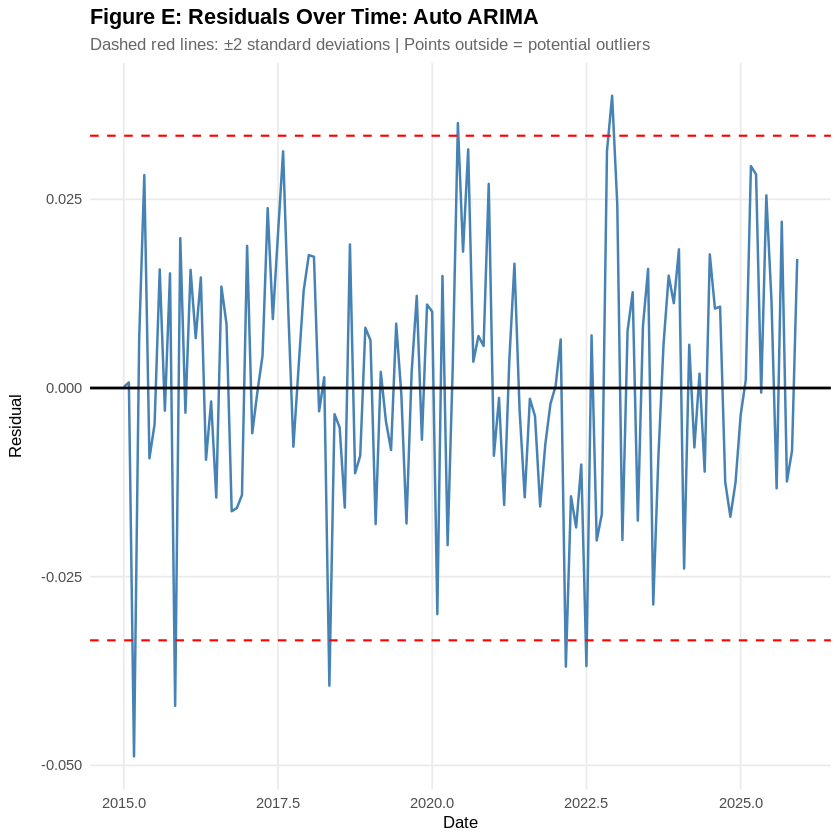

In [ ]:
cat("Residual Diagnostics:", best_label, "\n\n")

resid_vals <- as.numeric(residuals(best_model))
resid_ts   <- ts(resid_vals, start = start(rer_ts), frequency = 12)


resid_df <- data.frame(
  Date     = time(resid_ts),
  Residual = resid_vals
)

p_resid_time <- ggplot(resid_df, aes(x = Date, y = Residual)) +
  geom_line(colour = "steelblue", linewidth = 0.7) +
  geom_hline(yintercept = 0,    colour = "black",  linewidth = 0.8) +
  geom_hline(yintercept =  2*sd(resid_vals), colour = "red",
             linetype = "dashed", linewidth = 0.6) +
  geom_hline(yintercept = -2*sd(resid_vals), colour = "red",
             linetype = "dashed", linewidth = 0.6) +
  labs(title    = paste("Figure E: Residuals Over Time:", best_label),
       subtitle = "Dashed red lines: ±2 standard deviations | Points outside = potential outliers",
       x = "Date", y = "Residual") +
  theme_ec6011

print(p_resid_time)



####Residual histogram with normal curve overlay

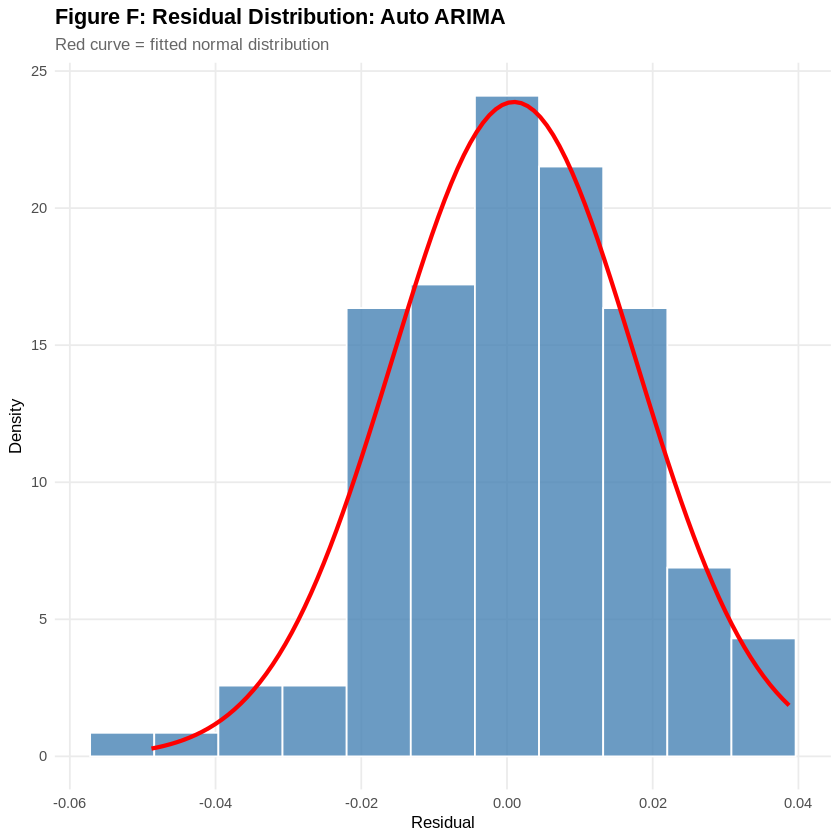

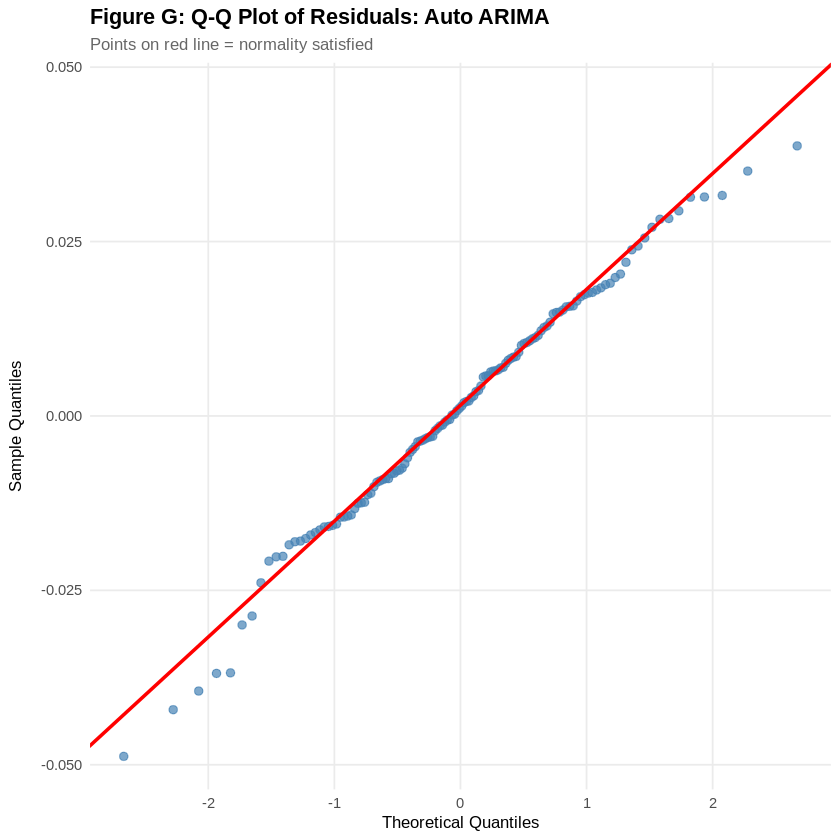

In [ ]:
bw <- 2 * IQR(resid_vals) / length(resid_vals)^(1/3)  # Freedman-Diaconis bin width

p_resid_hist <- ggplot(resid_df, aes(x = Residual)) +
  geom_histogram(aes(y = after_stat(density)),
                 binwidth = bw,
                 fill = "steelblue", colour = "white", alpha = 0.8) +
  stat_function(fun  = dnorm,
                args = list(mean = mean(resid_vals), sd = sd(resid_vals)),
                colour = "red", linewidth = 1.2) +
  labs(title    = paste("Figure F: Residual Distribution:", best_label),
       subtitle = "Red curve = fitted normal distribution",
       x = "Residual", y = "Density") +
  theme_ec6011

print(p_resid_hist)


# A Q-Q plot - Points lying on the diagonal = normally distributed residuals
p_qq <- ggplot(resid_df, aes(sample = Residual)) +
  stat_qq(colour = "steelblue", size = 2, alpha = 0.7) +
  stat_qq_line(colour = "red", linewidth = 1) +
  labs(title    = paste("Figure G: Q-Q Plot of Residuals:", best_label),
       subtitle = "Points on red line = normality satisfied",
       x = "Theoretical Quantiles", y = "Sample Quantiles") +
  theme_ec6011

print(p_qq)


####FITTED vs ACTUAL OVERLAY

Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


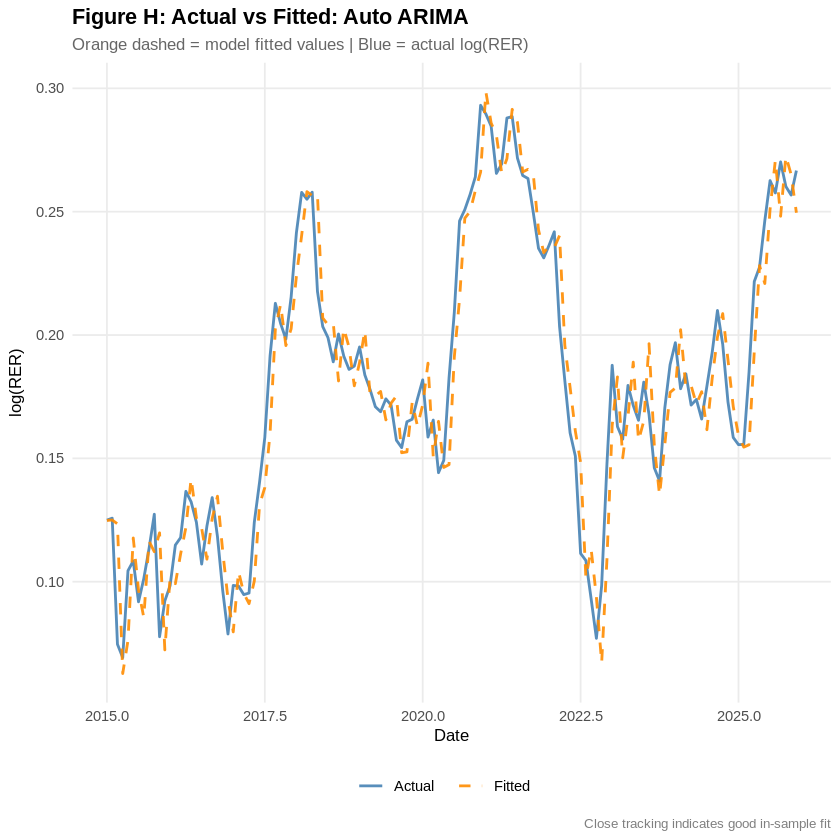

In [ ]:
# Purpose: Show how closely the best model tracks the actual log(RER) series in-sample. Visually confirms model adequacy.

fitted_vals <- as.numeric(fitted(best_model))
actual_vals <- as.numeric(rer_ts)
time_vals   <- time(rer_ts)

fit_df <- data.frame(
  Date    = time_vals,
  Actual  = actual_vals,
  Fitted  = fitted_vals,
  Residual = actual_vals - fitted_vals
)

p_fitted <- ggplot(fit_df, aes(x = Date)) +
  geom_line(aes(y = Actual, colour = "Actual"),
            linewidth = 0.8, alpha = 0.9) +
  geom_line(aes(y = Fitted, colour = "Fitted"),
            linewidth = 0.8, linetype = "dashed", alpha = 0.9) +
  scale_colour_manual(values = c("Actual" = "steelblue",
                                  "Fitted" = "darkorange")) +
  labs(title    = paste("Figure H: Actual vs Fitted:", best_label),
       subtitle = "Orange dashed = model fitted values | Blue = actual log(RER)",
       x = "Date", y = "log(RER)",
       caption  = "Close tracking indicates good in-sample fit") +
  theme_ec6011

print(p_fitted)


####RESIDUALS vs FITTED (SCATTER)

`geom_smooth()` using formula = 'y ~ x'



Estimation and Diagnostics Complete: 
Best model: Auto ARIMA 


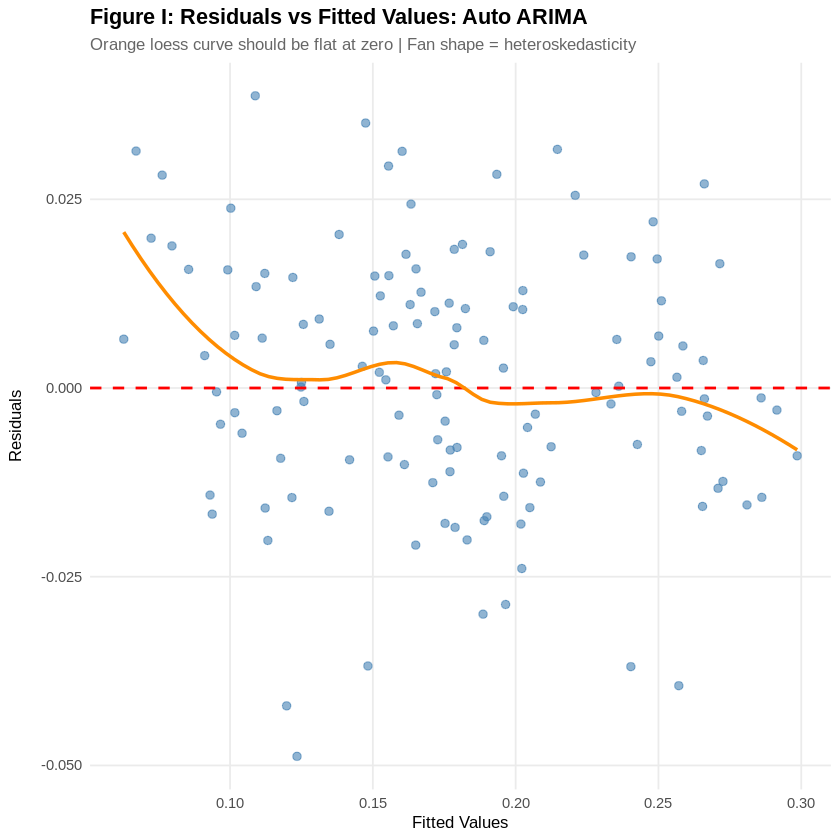

In [ ]:
# Purpose: Check for heteroskedasticity. If variance of residuals increases with fitted values, standard errors are unreliable. We want a random horizontal band centred on zero.

p_resfit <- ggplot(fit_df, aes(x = Fitted, y = Residual)) +
  geom_point(colour = "steelblue", size = 2, alpha = 0.6) +
  geom_hline(yintercept = 0, colour = "red",
             linetype = "dashed", linewidth = 0.8) +
  geom_smooth(method = "loess", se = FALSE,
              colour = "darkorange", linewidth = 1,
              linetype = "solid") +
  labs(title    = paste("Figure I: Residuals vs Fitted Values:", best_label),
       subtitle = "Orange loess curve should be flat at zero | Fan shape = heteroskedasticity",
       x = "Fitted Values", y = "Residuals") +
  theme_ec6011

print(p_resfit)


cat("\nEstimation and Diagnostics Complete: \n")
cat("Best model:", best_label, "\n")



##**STEP-7: BOX JENKINS Modelling - Forecasting**

##### GENERATE 12-MONTH AHEAD FORECAST - Produce point forecasts and prediction intervals (80% and 95%) for January 2026 to December 2026.


12-Month Ahead Forecasts - log(RER): 
         Point Forecast     Lo 80     Hi 80     Lo 95     Hi 95
Jan 2026      0.2698535 0.2480654 0.2916416 0.2365315 0.3031755
Feb 2026      0.2753797 0.2403611 0.3103984 0.2218234 0.3289361
Mar 2026      0.2705988 0.2263923 0.3148052 0.2029908 0.3382067
Apr 2026      0.2685677 0.2187444 0.3183910 0.1923695 0.3447658
May 2026      0.2730102 0.2172457 0.3287747 0.1877257 0.3582947
Jun 2026      0.2725875 0.2105767 0.3345982 0.1777502 0.3674248
Jul 2026      0.2694652 0.2027229 0.3362075 0.1673917 0.3715388
Aug 2026      0.2711394 0.2001454 0.3421333 0.1625634 0.3797153
Sep 2026      0.2727341 0.1970508 0.3484174 0.1569865 0.3884817
Oct 2026      0.2707938 0.1908651 0.3507224 0.1485534 0.3930341
Nov 2026      0.2704518 0.1868752 0.3540283 0.1426324 0.3982711
Dec 2026      0.2720447 0.1847026 0.3593869 0.1384665 0.4056230

Back-Transformed Forecasts: Original RER Scale
   Month LogRER_Pt RER_Point RER_Lo80 RER_Hi80 RER_Lo95 RER_Hi95
 2026-01    0.26

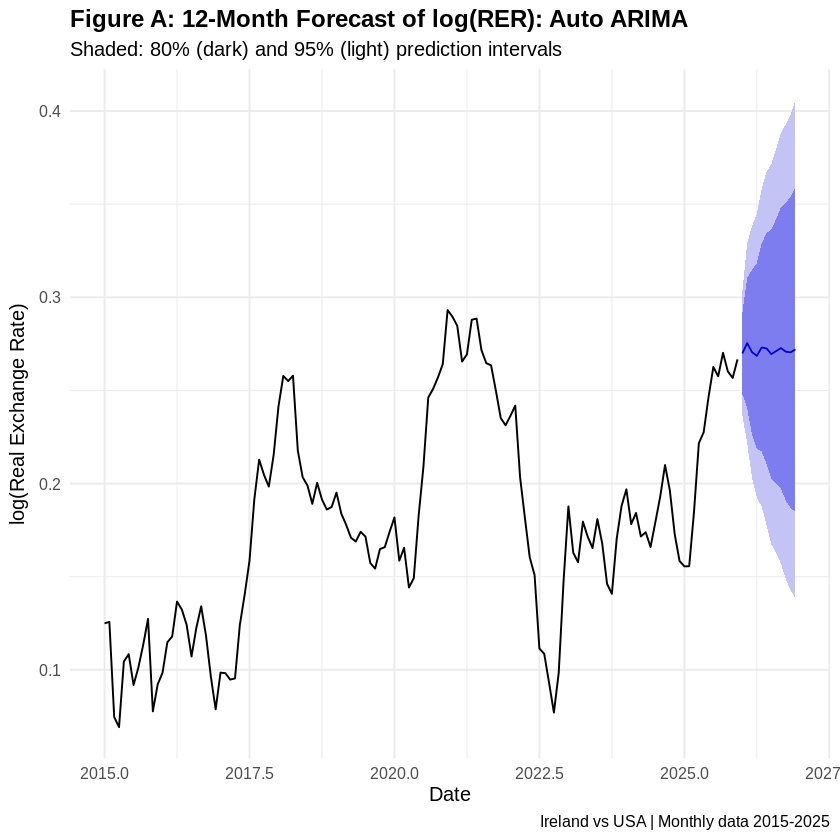

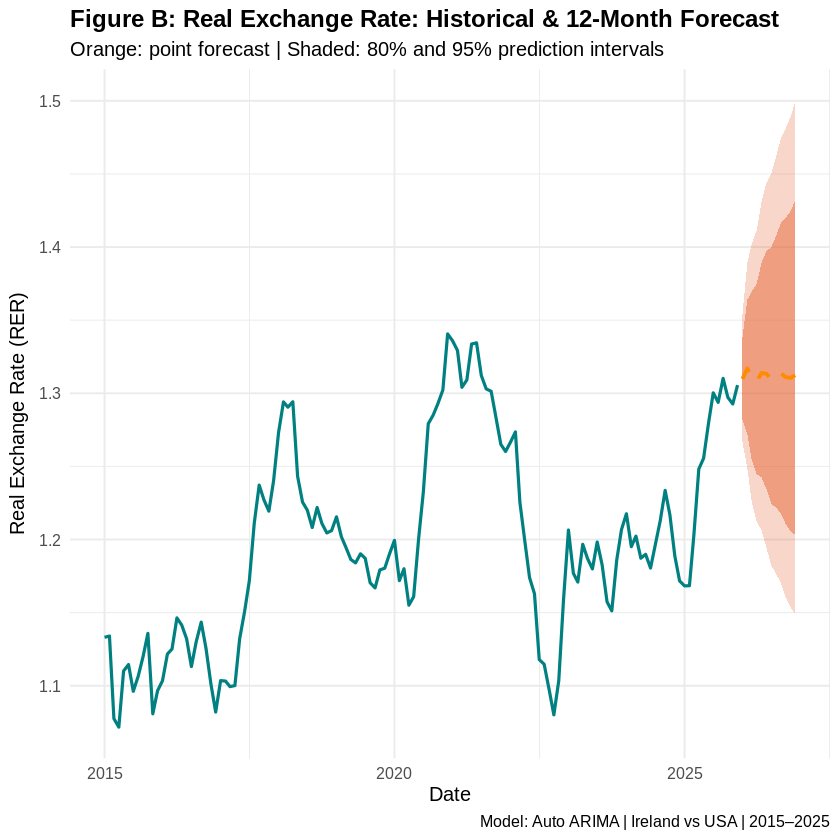

In [ ]:
h  <- 12   # Forecast horizon: 12 months

fc <- forecast(best_model, h = h, level = c(80, 95))

cat("\n12-Month Ahead Forecasts - log(RER): \n")
print(fc)

# Plot the forecast with shaded confidence bands
p_forecast <- autoplot(fc) +
  labs(title    = paste("Figure A: 12-Month Forecast of log(RER):", best_label),
       subtitle = "Shaded: 80% (dark) and 95% (light) prediction intervals",
       x        = "Date",
       y        = "log(Real Exchange Rate)",
       caption  = "Ireland vs USA | Monthly data 2015-2025") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

print(p_forecast)


# BACK-TRANSFORM FORECASTS TO ORIGINAL RER SCALE
# We modelled log(RER), so point forecasts are in log units. This makes them directly interpretable as EUR/USD real exchange rates.

forecast_dates <- seq(as.Date("2026-01-01"), by = "month", length.out = h)

rer_forecast_table <- data.frame(
  Month      = format(forecast_dates, "%Y-%m"),
  LogRER_Pt  = round(as.numeric(fc$mean),          4),   # Point forecast (log scale)
  RER_Point  = round(exp(as.numeric(fc$mean)),      4),   # Back-transformed point forecast
  RER_Lo80   = round(exp(fc$lower[, "80%"]),        4),   # Lower 80% PI
  RER_Hi80   = round(exp(fc$upper[, "80%"]),        4),   # Upper 80% PI
  RER_Lo95   = round(exp(fc$lower[, "95%"]),        4),   # Lower 95% PI
  RER_Hi95   = round(exp(fc$upper[, "95%"]),        4)    # Upper 95% PI
)

cat("\nBack-Transformed Forecasts: Original RER Scale\n")
print(rer_forecast_table, row.names = FALSE)

history_df <- data.frame(
  Date  = df$date_obj,
  Value = df$rer,
  Type  = "Historical"
)

forecast_df <- data.frame(
  Date    = forecast_dates,
  Point   = rer_forecast_table$RER_Point,
  Lo80    = rer_forecast_table$RER_Lo80,
  Hi80    = rer_forecast_table$RER_Hi80,
  Lo95    = rer_forecast_table$RER_Lo95,
  Hi95    = rer_forecast_table$RER_Hi95
)

p_rer_forecast <- ggplot() +
  # Historical series
  geom_line(data = history_df,
            aes(x = Date, y = Value),
            colour = "#008080", linewidth = 0.9) +
  # 95% prediction interval ribbon
  geom_ribbon(data = forecast_df,
              aes(x = Date, ymin = Lo95, ymax = Hi95),
              fill = "#e45d29", alpha = 0.25) +
  # 80% prediction interval ribbon
  geom_ribbon(data = forecast_df,
              aes(x = Date, ymin = Lo80, ymax = Hi80),
              fill = "#e45d29", alpha = 0.45) +
  # Point forecast line
  geom_line(data = forecast_df,
            aes(x = Date, y = Point),
            colour = "darkorange", linewidth = 1.1, linetype = "dashed") +
  labs(title    = "Figure B: Real Exchange Rate: Historical & 12-Month Forecast",
       subtitle = "Orange: point forecast | Shaded: 80% and 95% prediction intervals",
       x = "Date", y = "Real Exchange Rate (RER)",
       caption  = paste("Model:", best_label, "| Ireland vs USA | 2015–2025")) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

print(p_rer_forecast)


In [ ]:
# Back-transform to original RER scale
rer_forecast_table <- data.frame(
  Month     = format(seq(as.Date("2026-01-01"), by="month", length.out=12), "%Y-%m"),
  RER_Point = round(exp(as.numeric(fc$mean)), 4),
  RER_Lo95  = round(exp(fc$lower[,"95%"]), 4),
  RER_Hi95  = round(exp(fc$upper[,"95%"]), 4)
)
print(rer_forecast_table)


     Month RER_Point RER_Lo95 RER_Hi95
1  2026-01    1.3098   1.2668   1.3542
2  2026-02    1.3170   1.2484   1.3895
3  2026-03    1.3107   1.2251   1.4024
4  2026-04    1.3081   1.2121   1.4117
5  2026-05    1.3139   1.2065   1.4309
6  2026-06    1.3134   1.1945   1.4440
7  2026-07    1.3093   1.1822   1.4500
8  2026-08    1.3115   1.1765   1.4619
9  2026-09    1.3136   1.1700   1.4747
10 2026-10    1.3110   1.1602   1.4815
11 2026-11    1.3106   1.1533   1.4892
12 2026-12    1.3126   1.1485   1.5002


#### OUT-OF-SAMPLE FORECAST ACCURACY EVALUATION


Out-of-Sample Forecast Accuracy (12-Month Hold-Out): 
Training set: Jan 2015 – Dec 2024 (120 obs)
Test set:     Jan 2025 – Dec 2025 (12 obs)

                   ME     RMSE      MAE       MPE      MAPE     MASE     ACF1
Training set 0.000253 0.016579 0.013262 -0.459247  9.100618 0.236287 0.014104
Test set     0.070544 0.081500 0.072175 27.875300 28.923474 1.285953 0.742349
             Theil's U
Training set        NA
Test set      3.779082


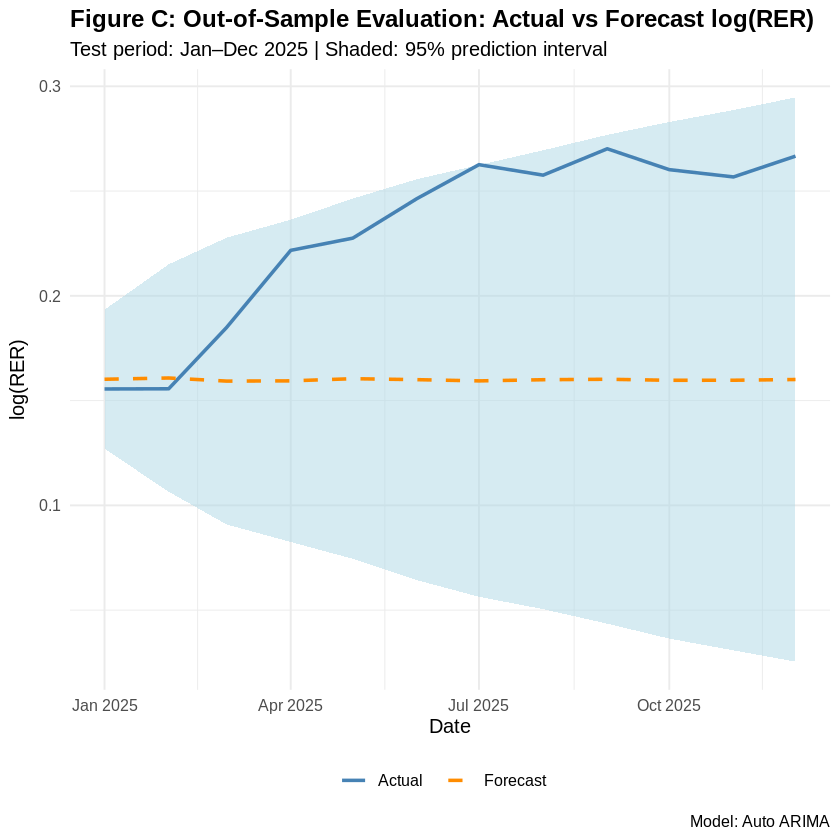

In [ ]:
n_total <- length(rer_ts)    # 132 total observations
n_train <- n_total - 12      # 120 training observations
n_test  <- 12                # 12 test observations

# Split into training and test windows using window()
rer_train <- window(rer_ts, end   = time(rer_ts)[n_train])
rer_test  <- window(rer_ts, start = time(rer_ts)[n_train + 1])

# Extract the p,d,q order from the best model and re-fit on training data only
best_order <- arimaorder(best_model)   # returns vector c(p, d, q)
m_train    <- Arima(rer_train,
                    order = c(best_order[1], best_order[2], best_order[3]),
                    method = "ML")

# Forecast 12 steps ahead from the training set
fc_eval <- forecast(m_train, h = n_test, level = c(80, 95))

# accuracy() computes: ME, RMSE, MAE, MPE, MAPE, MASE, ACF1
acc <- accuracy(fc_eval, rer_test)

cat("\nOut-of-Sample Forecast Accuracy (12-Month Hold-Out): \n")
cat("Training set: Jan 2015 – Dec 2024 (120 obs)\n")
cat("Test set:     Jan 2025 – Dec 2025 (12 obs)\n\n")
print(round(acc, 6))

test_dates <- df$date_obj[(n_train + 1):n_total]

eval_df <- data.frame(
  Date     = test_dates,
  Actual   = as.numeric(rer_test),
  Forecast = as.numeric(fc_eval$mean),
  Lo95     = as.numeric(fc_eval$lower[, "95%"]),
  Hi95     = as.numeric(fc_eval$upper[, "95%"])
)

p_eval <- ggplot(eval_df, aes(x = Date)) +
  geom_ribbon(aes(ymin = Lo95, ymax = Hi95), fill = "lightblue", alpha = 0.5) +
  geom_line(aes(y = Actual,   colour = "Actual"),   linewidth = 1.0) +
  geom_line(aes(y = Forecast, colour = "Forecast"), linewidth = 1.0, linetype = "dashed") +
  scale_colour_manual(values = c("Actual" = "steelblue", "Forecast" = "darkorange")) +
  labs(title    = "Figure C: Out-of-Sample Evaluation: Actual vs Forecast log(RER)",
       subtitle = "Test period: Jan–Dec 2025 | Shaded: 95% prediction interval",
       x = "Date", y = "log(RER)", colour = NULL,
       caption  = paste("Model:", best_label)) +
  theme_minimal(base_size = 12) +
  theme(plot.title    = element_text(face = "bold"),
        legend.position = "bottom")

print(p_eval)



####FULL IN-SAMPLE ACCURACY COMPARISON (ALL MODELS)

In [ ]:
# Summary of all 8 models in-sample accuracy for the report table

cat("\nIn-Sample Accuracy: All Models \n")
cat(sprintf("%-16s %8s %8s %8s %8s\n", "Model", "AIC", "BIC", "RMSE", "MAE"))
cat(strrep("-", 52), "\n")

for (i in seq_along(models_list)) {
  acc_i <- accuracy(models_list[[i]])
  cat(sprintf("%-16s %8.2f %8.2f %8.6f %8.6f\n",
              model_labels[i],
              AIC(models_list[[i]]),
              BIC(models_list[[i]]),
              acc_i[1, "RMSE"],
              acc_i[1, "MAE"]))
}

cat("Best model:", best_label, "\n")
cat("Forecast horizon: 12 months (Jan–Dec 2026)\n")




In-Sample Accuracy: All Models 
Model                 AIC      BIC     RMSE      MAE
---------------------------------------------------- 
ARIMA(0,1,0)      -679.96  -677.08 0.017852 0.013924
ARIMA(1,1,0)      -687.10  -681.35 0.017235 0.013346
ARIMA(0,1,1)      -688.41  -682.66 0.017149 0.013299
ARIMA(1,1,1)      -686.41  -677.79 0.017148 0.013297
ARIMA(2,1,0)      -687.07  -678.45 0.017104 0.013320
ARIMA(0,1,2)      -686.42  -677.79 0.017148 0.013296
ARIMA(2,1,2)      -689.12  -674.75 0.016676 0.013352
Auto ARIMA        -689.12  -674.75 0.016676 0.013352
Best model: Auto ARIMA 
Forecast horizon: 12 months (Jan–Dec 2026)


-------------------------------------------------------------
####  Conclusion: Best Model for our data analysis     : ARIMA(2,1,2) [Auto ARIMA]                
-------------------------------------------------------------